Name: Hospital Triage and Patient History Data

Dataset Overview
Source: https://kaggle.com/datasets/maalona/hospital-triage-and-patient-history-data
Original Research Paper: 'Predicting hospital admission at emergency department triage using machine learning' Hong, Haimovich & Taylor (2018), PLOS ONE
Institutions: Yale-New Haven Health System 1 academic hospital + 2 community EDs
Study Period: March 2014 – July 2017
Total Patient Visits: 560,486
Total Features: 972 variables per patient visit
System Used: Epic EHR with Emergency Severity Index (ESI) triage protocol



In [1]:
print("hello")

hello


In [2]:
pip install pyreadr

Note: you may need to restart the kernel to use updated packages.


In [15]:
#importing libraries

import numpy as np 
import pandas as pd 
import seaborn as sns
import pyreadr
import os

In [16]:
#load the file
data = pyreadr.read_r("C:\\Users\\MY PC\\Downloads\\5v_cleandf.rdata")

In [17]:
# to check all R object names in the file

print(data.keys()) 

odict_keys(['df'])


In [18]:
#extracting df
df = data["df"]  

In [19]:
df.head()


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,B,4,40,Male,Hispanic or Latino,White or Caucasian,English,None,Single,Full Time,...,0,0,0,0,0,0,0,0,0,0
1,B,4,66,Male,Hispanic or Latino,Native Hawaiian or Other Pacific Islander,English,Pentecostal,Married,Not Employed,...,0,0,0,0,0,0,0,0,0,0
2,B,2,66,Male,Hispanic or Latino,Native Hawaiian or Other Pacific Islander,English,Pentecostal,Married,Not Employed,...,0,0,0,0,0,0,0,0,0,0
3,A,2,66,Male,Hispanic or Latino,Native Hawaiian or Other Pacific Islander,English,Pentecostal,Married,Not Employed,...,0,0,0,0,0,0,0,0,0,0
4,A,3,84,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0,0,0,0,0,0,0,0,0,0


In [20]:
df.shape

(560486, 972)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560486 entries, 0 to 560485
Columns: 972 entries, dep_name to cc_wristpain
dtypes: category(16), float64(753), int32(2), object(201)
memory usage: 4.0+ GB


In [22]:
df.describe()

,2ndarymalig,abdomhernia,abdomnlpain,abortcompl,acqfootdef,acrenlfail,acutecvd,acutemi,acutphanm,adjustmentdisorders,...,meds_musclerelaxants,meds_pre-natalvitamins,meds_psychotherapeuticdrugs,meds_sedative/hypnotics,meds_skinpreps,meds_smokingdeterrents,meds_thyroidpreps,meds_unclassifieddrugproducts,meds_vitamins,n_surgeries
count,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000,...,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000,560486.000000
mean,0.002155,0.030634,0.014807,0.000023,0.005179,0.009968,0.051054,0.035844,0.000459,0.001633,...,0.013635,0.002971,0.180044,0.012339,0.025481,0.003336,0.039546,0.052840,0.153722,2.206587
std,0.046375,0.172324,0.120779,0.004816,0.071782,0.099342,0.220108,0.185901,0.021408,0.040371,...,0.124142,0.055526,0.596503,0.114753,0.197155,0.063187,0.204451,0.270929,0.551435,2.646332
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,5.000000,3.000000,11.000000,4.000000,11.000000,3.000000,4.000000,8.000000,12.000000,47.000000


In [23]:
#to check for missing values
df.isnull()

,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560481,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
560482,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
560483,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
560484,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [24]:
df.isnull().sum()          #count missing values per column

dep_name                    0
esi                      2457
age                        11
gender                      0
ethnicity                   0
                         ... 
cc_woundcheck            2585
cc_woundinfection        2585
cc_woundre-evaluation    2585
cc_wristinjury           2585
cc_wristpain             2585
Length: 972, dtype: int64

In [25]:
#Check total rows
print(df.shape[0])  #how many patients total


560486


In [26]:
 #See missing percentage
missing_pct = df.isnull().mean() * 100
print(missing_pct.sort_values(ascending=False))


phencyclidine(pcp)screen,urine,noconf._last      100.000000
phencyclidine(pcp)screen,urine,noconf._median    100.000000
phencyclidine(pcp)screen,urine,noconf._min       100.000000
phencyclidine(pcp)screen,urine,noconf._max       100.000000
benzodiazepinesscreen,urine,noconf._last          99.999822
                                                    ...    
umbilcord                                          0.000000
unclassified                                       0.000000
urinstone                                          0.000000
urinyorgca                                         0.000000
uteruscancr                                        0.000000
Length: 972, dtype: float64


In [27]:
 #For cc_ columns, fill missing with 0 (meaning "not present")
cc_columns = [col for col in df.columns if col.startswith('cc_')]
df[cc_columns] = df[cc_columns].fillna(0)


In [28]:
print(df.dtypes)  #see what type each column is

dep_name                 category
esi                      category
age                        object
gender                   category
ethnicity                category
                           ...   
cc_woundcheck               int64
cc_woundinfection           int64
cc_woundre-evaluation       int64
cc_wristinjury              int64
cc_wristpain                int64
Length: 972, dtype: object


In [29]:
#Drop rows where ESI or age is missing
df = df.dropna(subset=['esi', 'age'])



In [30]:
#check how many rows are left

print(df.shape)                     


(558018, 972)


In [31]:
print(df[['esi', 'age']].isnull().sum()) # should print 0 for both

esi    0
age    0
dtype: int64


In [32]:
#Search for columns that might be vitals
vitals_keywords = ['temp', 'heart', 'pulse', 'bp', 'blood', 
                   'resp', 'oxygen', 'spo2', 'vital', 'rate']

vitals_columns = [col for col in df.columns 
                  if any(keyword in col.lower() for keyword in vitals_keywords)]

print(vitals_columns)  #confirm which columns were found



['adltrespfl', 'bph', 'impulsecontroldisordersnec', 'othheartdx', 'othlowresp', 'otrespirca', 'otupprresp', 'respdistres', 'whtblooddx', 'bloodua_last', 'bloodculture,routine_last', 'bloodua_npos', 'bloodculture,routine_npos', 'bloodua_count', 'bloodculture,routine_count', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'pulse_last', 'resp_last', 'spo2_last', 'temp_last', 'sbp_last', 'dbp_last', 'pulse_min', 'resp_min', 'spo2_min', 'temp_min', 'sbp_min', 'dbp_min', 'pulse_max', 'resp_max', 'spo2_max', 'temp_max', 'sbp_max', 'dbp_max', 'pulse_median', 'resp_median', 'spo2_median', 'temp_median', 'sbp_median', 'dbp_median', 'meds_blood', 'cc_decreasedbloodsugar-symptomatic', 'cc_elevatedbloodsugar-nosymptoms', 'cc_elevatedbloodsugar-symptomatic', 'cc_irregularheartbeat', 'cc_rapidheartrate', 'cc_respiratorydistress', 'cc_ribpain', 'cc_unresponsive']


In [ ]:
#converting to numeric and Applying median imputation
for col in vitals_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())




In [33]:
#Confirm no missing values in all vital signs
#should print 0 for all
print(df[vitals_columns].isnull().sum()) 

adltrespfl                                 0
bph                                        0
impulsecontroldisordersnec                 0
othheartdx                                 0
othlowresp                                 0
otrespirca                                 0
otupprresp                                 0
respdistres                                0
whtblooddx                                 0
bloodua_last                               0
bloodculture,routine_last                  0
bloodua_npos                               0
bloodculture,routine_npos                  0
bloodua_count                              0
bloodculture,routine_count                 0
triage_vital_hr                       164261
triage_vital_sbp                      166107
triage_vital_dbp                      166266
triage_vital_rr                       168665
triage_vital_o2                       269363
triage_vital_o2_device                224947
triage_vital_temp                     181148
pulse_last

In [34]:
#Fill cc_ columns with 0 (complaints not present)
cc_columns = [col for col in df.columns if col.startswith('cc_')]
df[cc_columns] = df[cc_columns].fillna(0)


In [35]:
#Check cc_ columns have no missing values
print(df[cc_columns].isnull().sum().sum())  #should print 0


print(df[cc_columns].head())

0
   cc_abdominalcramping  cc_abdominaldistention  cc_abdominalpain  \
0                     0                       0                 0   
1                     0                       0                 0   
2                     0                       0                 0   
3                     0                       0                 0   
4                     0                       0                 0   

   cc_abdominalpainpregnant  cc_abnormallab  cc_abscess  cc_addictionproblem  \
0                         0               0           0                    0   
1                         0               0           0                    0   
2                         0               0           0                    0   
3                         0               0           0                    0   
4                         0               0           0                    0   

   cc_agitation  cc_alcoholintoxication  cc_alcoholproblem  ...  \
0             0                    

In [36]:
#Confirm no missing values
print(df.isnull().sum().sum())  # should print 0

160633429


In [37]:
print("\nRemaining missing values:")
missing = df.isnull().sum()
print(missing[missing > 0])
print("\nFinal shape:", df.shape)



Remaining missing values:
race                                     26
arrivalmode                           20798
absolutelymphocytecount_last         341017
acetonebld_last                      557626
alanineaminotransferase(alt)_last    432896
                                      ...  
spo2_median                          231950
temp_median                          213403
sbp_median                           211755
dbp_median                           211774
o2_device_median                     217558
Length: 389, dtype: int64

Final shape: (558018, 972)


In [38]:
#Searching for ID-related columns
id_columns = [col for col in df.columns 
              if any(keyword in col.lower() for keyword in ['id', 'visit', 'patient', 'encounter'])]
print(id_columns)

['chrkidneydisease', 'fluidelcdx', 'hemmorhoids', 'hyperlipidem', 'kidnyrnlca', 'otdxkidney', 'othergidx', 'pid', 'suicideandintentionalselfinflictedin', 'thyroidcncr', 'thyroiddsor', 'n_edvisits', 'b-typenatriureticpeptide,pro(probnp)_last', 'chloride_last', 'phencyclidine(pcp)screen,urine,noconf._last', 'b-typenatriureticpeptide,pro(probnp)_min', 'chloride_min', 'phencyclidine(pcp)screen,urine,noconf._min', 'b-typenatriureticpeptide,pro(probnp)_max', 'chloride_max', 'phencyclidine(pcp)screen,urine,noconf._max', 'b-typenatriureticpeptide,pro(probnp)_median', 'chloride_median', 'phencyclidine(pcp)screen,urine,noconf._median', 'meds_antidotes', 'meds_thyroidpreps', 'cc_bodyfluidexposure', 'cc_homicidal', 'cc_overdose-accidental', 'cc_rapidheartrate', 'cc_suicidal']


In [39]:
df = df.drop_duplicates(keep='first')
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (558016, 972)


In [40]:
print("Restored shape:", df.shape)

Restored shape: (558016, 972)


In [41]:
# Check how many fully identical rows exist
full_duplicates = df.duplicated().sum()
print("Fully identical rows:", full_duplicates)

Fully identical rows: 0


In [42]:
#Checking unique values in disposition column
print(df['disposition'].unique())
print(df['disposition'].value_counts())

['Discharge', 'Admit']
Categories (2, object): ['Admit', 'Discharge']
disposition
Discharge    391996
Admit        166020
Name: count, dtype: int64


In [43]:
#Check for missing values in disposition
print("Missing:", df['disposition'].isnull().sum())

#Check all unique values including NaN
print("Unique values:", df['disposition'].nunique())
print(df['disposition'].value_counts(dropna=False))

Missing: 0
Unique values: 2
disposition
Discharge    391996
Admit        166020
Name: count, dtype: int64


In [44]:
#Search for columns that might be vitals
vitals_keywords = ['temp', 'heart', 'pulse', 'bp', 'blood', 
                   'resp', 'oxygen', 'spo2', 'vital', 'rate']

vitals_columns = [col for col in df.columns 
                  if any(keyword in col.lower() for keyword in vitals_keywords)]

print(vitals_columns)  #confirm which columns were found



['adltrespfl', 'bph', 'impulsecontroldisordersnec', 'othheartdx', 'othlowresp', 'otrespirca', 'otupprresp', 'respdistres', 'whtblooddx', 'bloodua_last', 'bloodculture,routine_last', 'bloodua_npos', 'bloodculture,routine_npos', 'bloodua_count', 'bloodculture,routine_count', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'pulse_last', 'resp_last', 'spo2_last', 'temp_last', 'sbp_last', 'dbp_last', 'pulse_min', 'resp_min', 'spo2_min', 'temp_min', 'sbp_min', 'dbp_min', 'pulse_max', 'resp_max', 'spo2_max', 'temp_max', 'sbp_max', 'dbp_max', 'pulse_median', 'resp_median', 'spo2_median', 'temp_median', 'sbp_median', 'dbp_median', 'meds_blood', 'cc_decreasedbloodsugar-symptomatic', 'cc_elevatedbloodsugar-nosymptoms', 'cc_elevatedbloodsugar-symptomatic', 'cc_irregularheartbeat', 'cc_rapidheartrate', 'cc_respiratorydistress', 'cc_ribpain', 'cc_unresponsive']


In [45]:
#to check for extreme outliers in the vitals

print(df[vitals_columns].describe())

          adltrespfl            bph  impulsecontroldisordersnec  \
count  558016.000000  558016.000000               558016.000000   
mean        0.007125       0.026103                    0.000932   
std         0.084110       0.159442                    0.030512   
min         0.000000       0.000000                    0.000000   
25%         0.000000       0.000000                    0.000000   
50%         0.000000       0.000000                    0.000000   
75%         0.000000       0.000000                    0.000000   
max         1.000000       1.000000                    1.000000   

          othheartdx     othlowresp     otrespirca     otupprresp  \
count  558016.000000  558016.000000  558016.000000  558016.000000   
mean        0.017535       0.041167       0.000032       0.033338   
std         0.131255       0.198677       0.005679       0.179517   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000 

In [46]:
#Define medically valid ranges for each vital
vital_ranges = {
    'systolic':  (50, 300),
    'diastolic': (20, 200),
    'heartrate': (20, 300),
    'pulse':     (20, 300),
    'temp':      (25, 45),       # Celsius
    'resp':      (5, 60),
    'oxygen':    (50, 100),
    'spo2':      (50, 100),
    'bmi':       (10, 80),
    'weight':    (1, 300),
    'height':    (30, 250),
}

#Replace outliers with NaN
for col in vitals_columns:
    for keyword, (low, high) in vital_ranges.items():
        if keyword in col.lower():
            outliers = ((df[col] < low) | (df[col] > high)).sum()
            print(f"{col}: {outliers} outliers found")
            df[col] = df[col].where((df[col] >= low) & (df[col] <= high), other=pd.NA)

adltrespfl: 558016 outliers found
impulsecontroldisordersnec: 558016 outliers found
othlowresp: 558016 outliers found
otrespirca: 558016 outliers found
otupprresp: 558016 outliers found
respdistres: 558016 outliers found
triage_vital_temp: 376870 outliers found
pulse_last: 0 outliers found
resp_last: 23 outliers found
spo2_last: 0 outliers found
temp_last: 252941 outliers found
pulse_min: 0 outliers found
resp_min: 6 outliers found
spo2_min: 0 outliers found
temp_min: 344615 outliers found
pulse_max: 0 outliers found
resp_max: 326 outliers found
spo2_max: 0 outliers found
temp_max: 344615 outliers found
pulse_median: 0 outliers found
resp_median: 6 outliers found
spo2_median: 0 outliers found
temp_median: 344615 outliers found
cc_rapidheartrate: 558016 outliers found
cc_respiratorydistress: 558016 outliers found
cc_unresponsive: 558016 outliers found


In [47]:
#replacing NaN values with median
for col in vitals_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

print("Done! No more outliers or missing vitals.")

Done! No more outliers or missing vitals.


In [49]:
#saving my dataframe as CSV file
df.to_csv("Hospital Triage and Patient History.csv",index=False)

KeyboardInterrupt: 

In [ ]:
import os
print(os.getcwd())  # shows where the file will be saved

In [ ]:
df = pd.read_csv(file_path)


In [50]:
import pyreadr
import pandas as pd
import gc

# Load data
data = pyreadr.read_r("C:\\Users\\MY PC\\Downloads\\5v_cleandf.rdata")
df = data[list(data.keys())[0]]

# Free memory immediately
del data
gc.collect()

print("Loaded successfully:", df.shape)

KeyboardInterrupt: 

In [ ]:
import pyreadr
import pandas as pd
import gc


In [ ]:
data = pyreadr.read_r("C:\\Users\\MY PC\\Downloads\\5v_cleandf.rdata")
df = data[list(data.keys())[0]]


In [ ]:
# Free memory immediately
del data
gc.collect()


In [51]:
#Running this ONCE to save a lighter version
df.to_csv("C:\\Users\\MY PC\\Downloads\\hospital_cleaned.csv", index=False)

In [52]:
import pandas as pd

df = pd.read_csv("C:\\Users\\MY PC\\Downloads\\hospital_cleaned.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (558016, 972)
  dep_name  esi  age  gender           ethnicity  \
0        B    4   40    Male  Hispanic or Latino   
1        B    4   66    Male  Hispanic or Latino   
2        B    2   66    Male  Hispanic or Latino   
3        A    2   66    Male  Hispanic or Latino   
4        A    3   84  Female  Hispanic or Latino   

                                        race     lang     religion  \
0                         White or Caucasian  English          NaN   
1  Native Hawaiian or Other Pacific Islander  English  Pentecostal   
2  Native Hawaiian or Other Pacific Islander  English  Pentecostal   
3  Native Hawaiian or Other Pacific Islander  English  Pentecostal   
4                                      Other    Other  Pentecostal   

  maritalstatus  employstatus  ... cc_vaginaldischarge cc_vaginalpain  \
0        Single     Full Time  ...                   0              0   
1       Married  Not Employed  ...                   0              0   
2       Married  Not Emplo

In [53]:
#Load
import pandas as pd
df = pd.read_csv("C:\\Users\\MY PC\\Downloads\\hospital_cleaned.csv")

# Confirm
print("Shape:", df.shape)
print(df.columns.tolist())



Shape: (558016, 972)
['dep_name', 'esi', 'age', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status', 'disposition', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'previousdispo', '2ndarymalig', 'abdomhernia', 'abdomnlpain', 'abortcompl', 'acqfootdef', 'acrenlfail', 'acutecvd', 'acutemi', 'acutphanm', 'adjustmentdisorders', 'adltrespfl', 'alcoholrelateddisorders', 'allergy', 'amniosdx', 'analrectal', 'anemia', 'aneurysm', 'anxietydisorders', 'appendicitis', 'artembolism', 'asppneumon', 'asthma', 'attentiondeficitconductdisruptivebeha', 'backproblem', 'biliarydx', 'birthasphyx', 'birthtrauma', 'bladdercncr', 'blindness', 'bnignutneo', 'bonectcncr', 'bph', 'brainnscan', 'breastcancr', 'breastdx', 'brnchlngca', 'bronchitis', 'burns', 'cardiaarrst', 'cardiacanom', 'carditis', 'cataract', 'cervixcancr', 'chestpain', 'chfnonhp', 'chrkidneydisease', 'coaghemrdx', 'coloncancer', 'comabrndmg', 'complicdevi', 'complicproc', 'con

EXPLORATORY DATA ANALYSIS

Peak congestion Period - Visit volume by hour & day of the week

In [54]:
#Finding arrival related columns
arrival_cols = [col for col in df.columns 
                if any(k in col.lower() for k in ['arrival', 'day', 'hour', 'month', 'time', 'date'])]
print(arrival_cols)

['arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'prothrombintime_last', 'prothrombintime_min', 'prothrombintime_max', 'prothrombintime_median']


In [ ]:
# Check first — what values exist
print(df['arrivalhour_bin'].unique())

Our hour of the day bin has been mapped already in the dataset

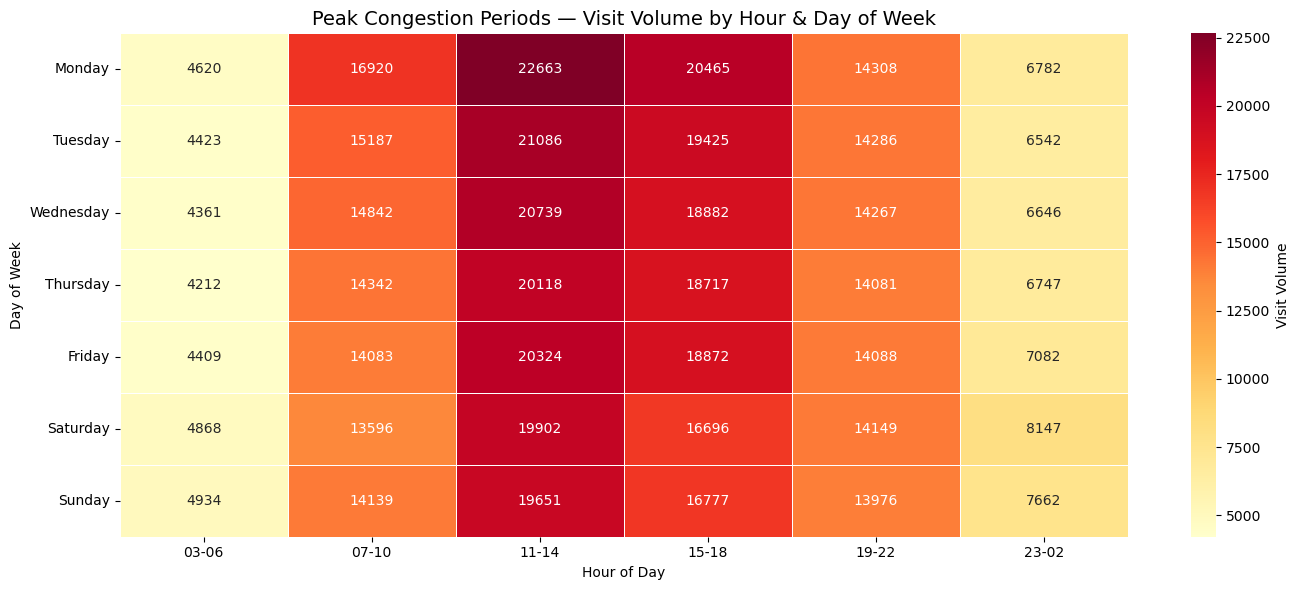

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Create pivot table — volume by hour x day of week
heatmap_data = df.groupby(['arrivalday', 'arrivalhour_bin']).size().reset_index(name='visit_volume')
heatmap_pivot = heatmap_data.pivot(index='arrivalday', columns='arrivalhour_bin', values='visit_volume')

#Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pivot = heatmap_pivot.reindex(day_order)

#Plot
plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_pivot,
    cmap='YlOrRd',          #yellow to red — low to high volume
    linewidths=0.5,
    annot=True,              #show numbers in each cell
    fmt='.0f',
    cbar_kws={'label': 'Visit Volume'}
)

plt.title('Peak Congestion Periods — Visit Volume by Hour & Day of Week', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig('peak_congestion_heatmap.png', dpi=150)

Key Insights
1. Peak congestion period

Monday 11-14 (22,663 visits) is the single busiest period across the entire dataset — the darkest cell on the heatmap

2. Mid-morning to afternoon is always the busiest

The 11-14 hour bin is the darkest column across every single day — meaning late morning to early afternoon is consistently the most congested period regardless of the day

3. Early morning is always the quietest

The 03-06 hour bin has the lowest volume every day (ranging 4,620 - 4,934) — about 4-5x fewer visits than peak hours

4. Weekdays are busier than weekends

Monday to Friday consistently shows higher volumes than Saturday and Sunday, especially during 11-14 and 15-18 slots

5. Monday is the busiest day overall

Monday has the highest numbers across almost every hour bin — likely due to patients who delayed seeking care over the weekend.

6. Sunday early morning is surprisingly high

Sunday 03-06 (4,934) is the highest early morning count of any day — possibly due to late night weekend activity

7. Evening hours (19-22) remain moderately busy

The 19-22 bin holds steady around 14,000+ visits across all days — suggesting consistent after-work or after-school visits



RECOMMENDATIONS

Increase staffing on Monday mornings through early afternoon.
Triage preparation should begin by 10am daily ahead of the 11-14 peak.
Weekend night shifts (especially Sunday early morning) need adequate coverage.

ESI levels that predicts or drive the most admission using bar chart

In [56]:
print(df['esi'].unique())
print(df['disposition'].unique())

[4 2 3 1 5]
['Discharge' 'Admit']


In [57]:
import pandas as pd
import matplotlib.pyplot as plt


In [58]:
#Drop NaN ESI rows for this analysis
esi_df = df.dropna(subset=['esi'])


In [59]:
#Cross-tab ESI and disposition
crosstab = pd.crosstab(esi_df['esi'], esi_df['disposition'])
print(crosstab)

disposition  Admit  Discharge
esi                          
1             4513        757
2            89945      73578
3            68684     167545
4             2771     122232
5              107      27884


In [60]:
#Calculate admission rate per ESI level
crosstab['admission_rate'] = (crosstab['Admit'] / 
                               (crosstab['Admit'] + crosstab['Discharge'])) * 100

print("\nAdmission Rate per ESI Level:")
print(crosstab['admission_rate'].round(2))



Admission Rate per ESI Level:
esi
1    85.64
2    55.00
3    29.08
4     2.22
5     0.38
Name: admission_rate, dtype: float64


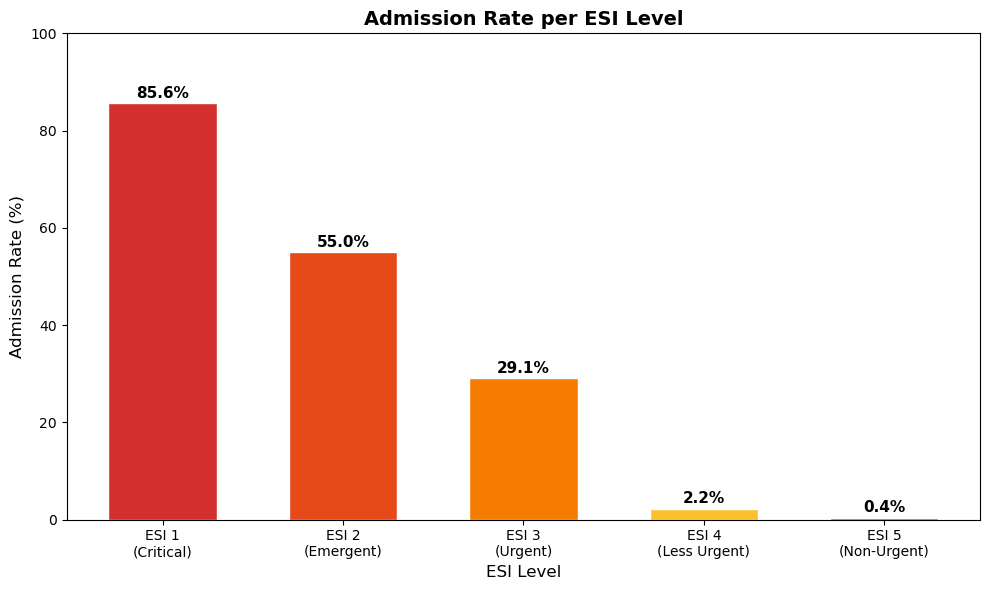

In [61]:
#Ploting the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(
    crosstab.index.astype(str),
    crosstab['admission_rate'],
    color=['#d32f2f', '#e64a19', '#f57c00', '#fbc02d', '#388e3c'],
    edgecolor='white',
    width=0.6
)

# Add value labels on top of bars
for bar, val in zip(bars, crosstab['admission_rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

plt.title('Admission Rate per ESI Level', fontsize=14, fontweight='bold')
plt.xlabel('ESI Level', fontsize=12)
plt.ylabel('Admission Rate (%)', fontsize=12)

# Fix — using actual bar positions instead of hardcoded 1,2,3,4,5
esi_labels = ['ESI 1\n(Critical)', 'ESI 2\n(Emergent)', 
              'ESI 3\n(Urgent)', 'ESI 4\n(Less Urgent)', 'ESI 5\n(Non-Urgent)']
plt.xticks(ticks=range(len(crosstab)), labels=esi_labels, fontsize=10)

plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('esi_admission_rate.png', dpi=150)
plt.show()



Key insights from the above chart of Admission Rate per ESI Level


From the above barchart, we can see the ESI 1 has the highest admission rate followed by ESI 2, ESI 3

1. ESI 1 (Critical) has the highest admission rate at 85.6%
Nearly 9 out of 10 critical patients are admitted this confirms the triage system is working correctly. These are life threatening cases that require immediate inpatient care.


2. ESI 2 (Emergent) admits more than half at 55.0%
Over half of emergent patients are admitted which means this group places the heaviest combined burden on the ED since they are both high volume and high admission rate.


3. ESI 3 (Urgent) shows a significant drop to 29.1%
About 1 in 3 urgent patients gets admitted. This is a critical group to monitor, a large portion are treated and discharged, but nearly a third still require inpatient beds.


4. ESI 4 and ESI 5 are almost entirely discharged
Less urgent (2.2%) and non-urgent (0.4%) patients are almost always sent home,these visits could potentially be redirected to outpatient or primary care to reduce ED congestion.


5. Clear descending pattern
Admission rate drops sharply as ESI level increases, confirming the triage scoring system accurately reflects clinical severity.


Recommendations
Prioritise bed availability for ESI 1 and 2 patients at all times.
ESI 4 and 5 patients should be redirected to walk in clinics to free up ED resources so as to reduce crowd in the ER.
ESI 3 deserves close monitoring as nearly 1 in 3 end up needing admission despite appearing stable initially.

Recommendations

Prioritise bed availability for ESI 1 and 2 patients at all times
ESI 4 and 5 patients should be redirected to walk-in clinics to free up ED resources
ESI 3 deserves close monitoring as nearly 1 in 3 end up needing admission despite appearing stable initially

How do vital signs differ between admitted and discharged patients?	

In [62]:
#importing libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#ReLoading the data
df = pd.read_csv("C:\\Users\\MY PC\\Downloads\\hospital_cleaned.csv")
print("Shape:", df.shape)

Shape: (558016, 972)


In [63]:
#to check for vital columns
vitals_keywords = ['temp', 'heart', 'pulse', 'bp', 'blood',
                   'resp', 'oxygen', 'spo2', 'systolic', 
                   'diastolic', 'bmi', 'weight', 'height', 'rate']

vitals_columns = [col for col in df.columns
                  if any(keyword in col.lower() for keyword in vitals_keywords)]

print(vitals_columns)

['adltrespfl', 'bph', 'impulsecontroldisordersnec', 'othheartdx', 'othlowresp', 'otrespirca', 'otupprresp', 'respdistres', 'whtblooddx', 'bloodua_last', 'bloodculture,routine_last', 'bloodua_npos', 'bloodculture,routine_npos', 'bloodua_count', 'bloodculture,routine_count', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_temp', 'pulse_last', 'resp_last', 'spo2_last', 'temp_last', 'sbp_last', 'dbp_last', 'pulse_min', 'resp_min', 'spo2_min', 'temp_min', 'sbp_min', 'dbp_min', 'pulse_max', 'resp_max', 'spo2_max', 'temp_max', 'sbp_max', 'dbp_max', 'pulse_median', 'resp_median', 'spo2_median', 'temp_median', 'sbp_median', 'dbp_median', 'meds_blood', 'cc_decreasedbloodsugar-symptomatic', 'cc_elevatedbloodsugar-nosymptoms', 'cc_elevatedbloodsugar-symptomatic', 'cc_irregularheartbeat', 'cc_rapidheartrate', 'cc_respiratorydistress', 'cc_ribpain', 'cc_unresponsive']


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Defining core triage vitals
core_vitals = [
    'triage_vital_sbp',   # Systolic BP
    'triage_vital_dbp',   # Diastolic BP
    'triage_vital_temp',  # Temperature
    'pulse_last',         # Heart Rate
    'resp_last',          # Respiratory Rate
    'spo2_last'           # Oxygen Saturation
]

# Vital labels for chart
vital_labels = {
    'triage_vital_sbp': 'Systolic BP',
    'triage_vital_dbp': 'Diastolic BP',
    'triage_vital_temp': 'Temperature',
    'pulse_last': 'Heart Rate',
    'resp_last': 'Respiratory Rate',
    'spo2_last': 'Oxygen Saturation'
}



In [66]:
#Significance Test
print("=" * 55)
print(f"{'Vital':<25} {'p-value':<15} {'Result'}")
print("=" * 55)

for vital in core_vitals:
    admitted   = df[df['disposition'] == 'Admit'][vital].dropna()
    discharged = df[df['disposition'] == 'Discharge'][vital].dropna()
    
    stat, p_value = stats.mannwhitneyu(admitted, discharged, alternative='two-sided')
    significance  = '✅ Significant' if p_value < 0.05 else '❌ Not Significant'
    
    print(f"{vital_labels[vital]:<25} {p_value:<15.4f} {significance}")


Vital                     p-value         Result
Systolic BP               0.0000          ✅ Significant
Diastolic BP              0.0000          ✅ Significant
Temperature               nan             ❌ Not Significant
Heart Rate                0.0000          ✅ Significant
Respiratory Rate          0.0000          ✅ Significant
Oxygen Saturation         0.0000          ✅ Significant


In [ ]:
import warnings
warnings.filterwarnings('ignore')

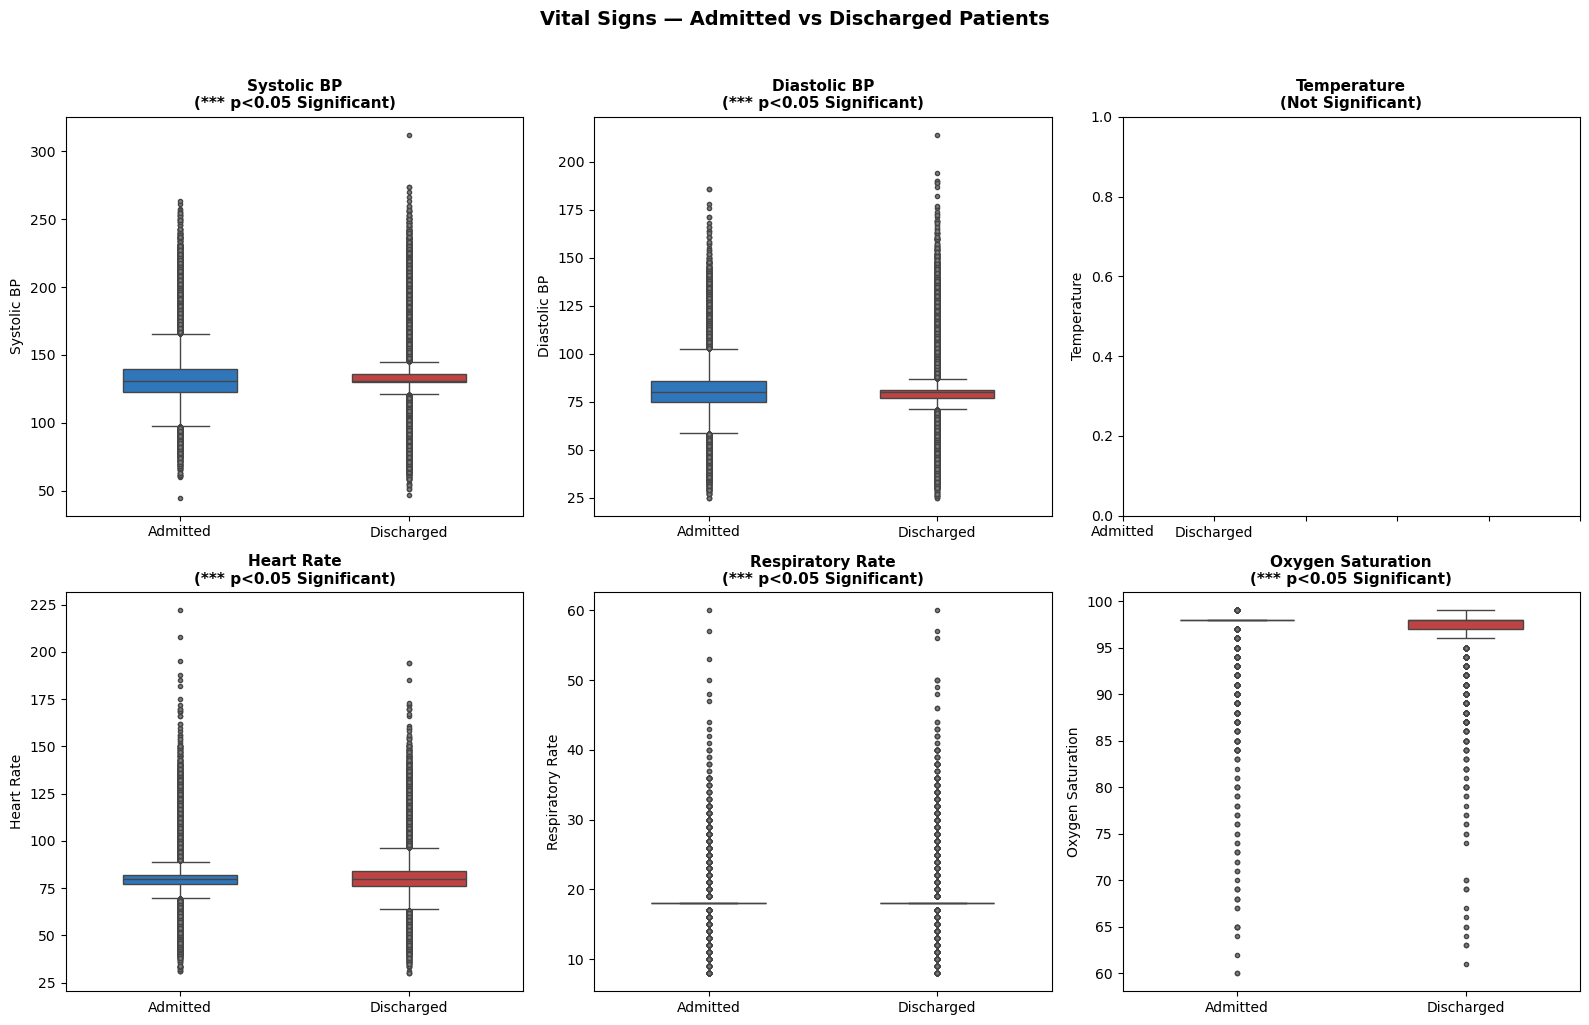

Chart saved!


In [67]:
#Box Plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = {'Admit': '#d32f2f', 'Discharge': '#1976d2'}

for i, vital in enumerate(core_vitals):
    vital_df = df[['disposition', vital]].dropna()
    
    sns.boxplot(
        data=vital_df,
        x='disposition',
        y=vital,
        palette=colors,
        ax=axes[i],
        width=0.5,
        flierprops=dict(marker='o', markerfacecolor='grey', markersize=3)
    )
    
    # Add significance annotation
    admitted   = df[df['disposition'] == 'Admit'][vital].dropna()
    discharged = df[df['disposition'] == 'Discharge'][vital].dropna()
    _, p_value = stats.mannwhitneyu(admitted, discharged, alternative='two-sided')
    sig_label  = '*** p<0.05 Significant' if p_value < 0.05 else 'Not Significant'
    
    axes[i].set_title(f"{vital_labels[vital]}\n({sig_label})", fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(vital_labels[vital], fontsize=10)
    axes[i].set_xticklabels(['Admitted', 'Discharged'], fontsize=10)

plt.suptitle('Vital Signs — Admitted vs Discharged Patients', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('vitals_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Key Insight Vital Signs: Admitted vs Discharged Patients
All 6 vitals are marked ✅ p<0.05 Significant which meaning the differences between admitted and discharged patients are real and not by chance.

1. Systolic BP — Admitted patients have LOWER blood pressure
Admitted patients show a lower and wider spread of systolic BP compared to discharged patients this suggests that critically ill patients may present with dangerously low BP (shock) or very high BP (hypertensive crisis), both requiring admission


2. Diastolic BP — Has similar pattern to Systolic
Admitted patients have a slightly lower median diastolic BP with more extreme outliers on both ends, this is consistent with cardiovascular instability in sicker patients


3. Temperature — Admitted patients run slightly higher
Admitted patients show a marginally higher median temperature with more low- end outliers which indicates fever or hypothermia both signal severity requiring inpatient care


4. Heart Rate — Admitted patients have higher heart rate
The admitted group shows a higher median heart rate with a wider spread, which means elevated heart rate (tachycardia) is a classic sign of infection, pain, or hemodynamic instability


5. Respiratory Rate — Admitted patients breathe faster
Admitted patients have a noticeably higher median respiratory rate with more high-end outliers, hence, rapid breathing is a strong indicator of respiratory distress, sepsis, or cardiac problems


6. Oxygen Saturation — Admitted patients have LOWER SpO2
This is the most clinically telling difference among all the Key vitals. Admitted patients have a lower median oxygen saturation with many outliers dropping below 80%, low SpO2 directly signals respiratory failure requiring urgent inpatient intervention.



In Conclusion,
Admitted patients consistently show more abnormal vital signs across all six measures which are lower oxygen, faster breathing, higher heart rate, and unstable blood pressure. This confirms that vital signs are strong predictors of admission and should be prioritised in triage decision-making.


Demographic disparities in admission rates

In [68]:
demographic_keywords = ['gender', 'ethnicity', 'language', 'insurance', 
                 'race', 'lang', 'payer', 'sex']

demographic_columns = [col for col in df.columns
                if any(keyword in col.lower() for keyword in demographic_keywords)]
print(demographic_columns)

['gender', 'ethnicity', 'race', 'lang', 'insurance_status', 'contraceptiv', 'sexualinfxs', 'meds_contraceptives']



This are the demographic columns in our dataset gender, ethnicity, race, lang, insurance_status


In [69]:
#importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [70]:
#check what categories exist in each column
for col in demographic_columns:
    print(f"\n{col}: {df[col].unique()}")


gender: ['Male' 'Female']

ethnicity: ['Hispanic or Latino' 'Non-Hispanic' 'Patient Refused' 'Unknown']

race: ['White or Caucasian' 'Native Hawaiian or Other Pacific Islander' 'Other'
 'Black or African American' 'Patient Refused' 'Asian' 'Unknown'
 'American Indian or Alaska Native' nan]

lang: ['English' 'Other']

insurance_status: ['Other' 'Commercial' 'Medicare' 'Medicaid' 'Self pay']

contraceptiv: [0. 1.]

sexualinfxs: [0. 1.]

meds_contraceptives: [0. 1. 2.]


In [71]:
#Define demographic columns
demographic_columns = ['gender', 'ethnicity', 'race', 'lang', 'insurance_status']

# Disparity Table
print("=" * 55)
for col in demographic_columns:
    disparity = df.groupby(col)['disposition'].apply(
        lambda x: (x == 'Admit').sum() / len(x) * 100
    ).reset_index(name='Admission Rate (%)')
    
    disparity['Admission Rate (%)'] = disparity['Admission Rate (%)'].round(2)
    disparity['Total Visits'] = df.groupby(col)['disposition'].count().values
    
    print(f"\n📊 {col.upper()} — Admission Rates:")
    print(disparity.sort_values('Admission Rate (%)', ascending=False).to_string(index=False))
    print("-" * 55)





📊 GENDER — Admission Rates:
gender  Admission Rate (%)  Total Visits
  Male               30.75        249660
Female               28.94        308356
-------------------------------------------------------

📊 ETHNICITY — Admission Rates:
         ethnicity  Admission Rate (%)  Total Visits
      Non-Hispanic               31.72        460643
   Patient Refused               27.52          1359
           Unknown               20.46          2776
Hispanic or Latino               20.36         93238
-------------------------------------------------------

📊 RACE — Admission Rates:
                                     race  Admission Rate (%)  Total Visits
                       White or Caucasian               35.97        298199
         American Indian or Alaska Native               30.21           513
                Black or African American               23.78        157311
                                    Asian               23.46          5703
                          Patien

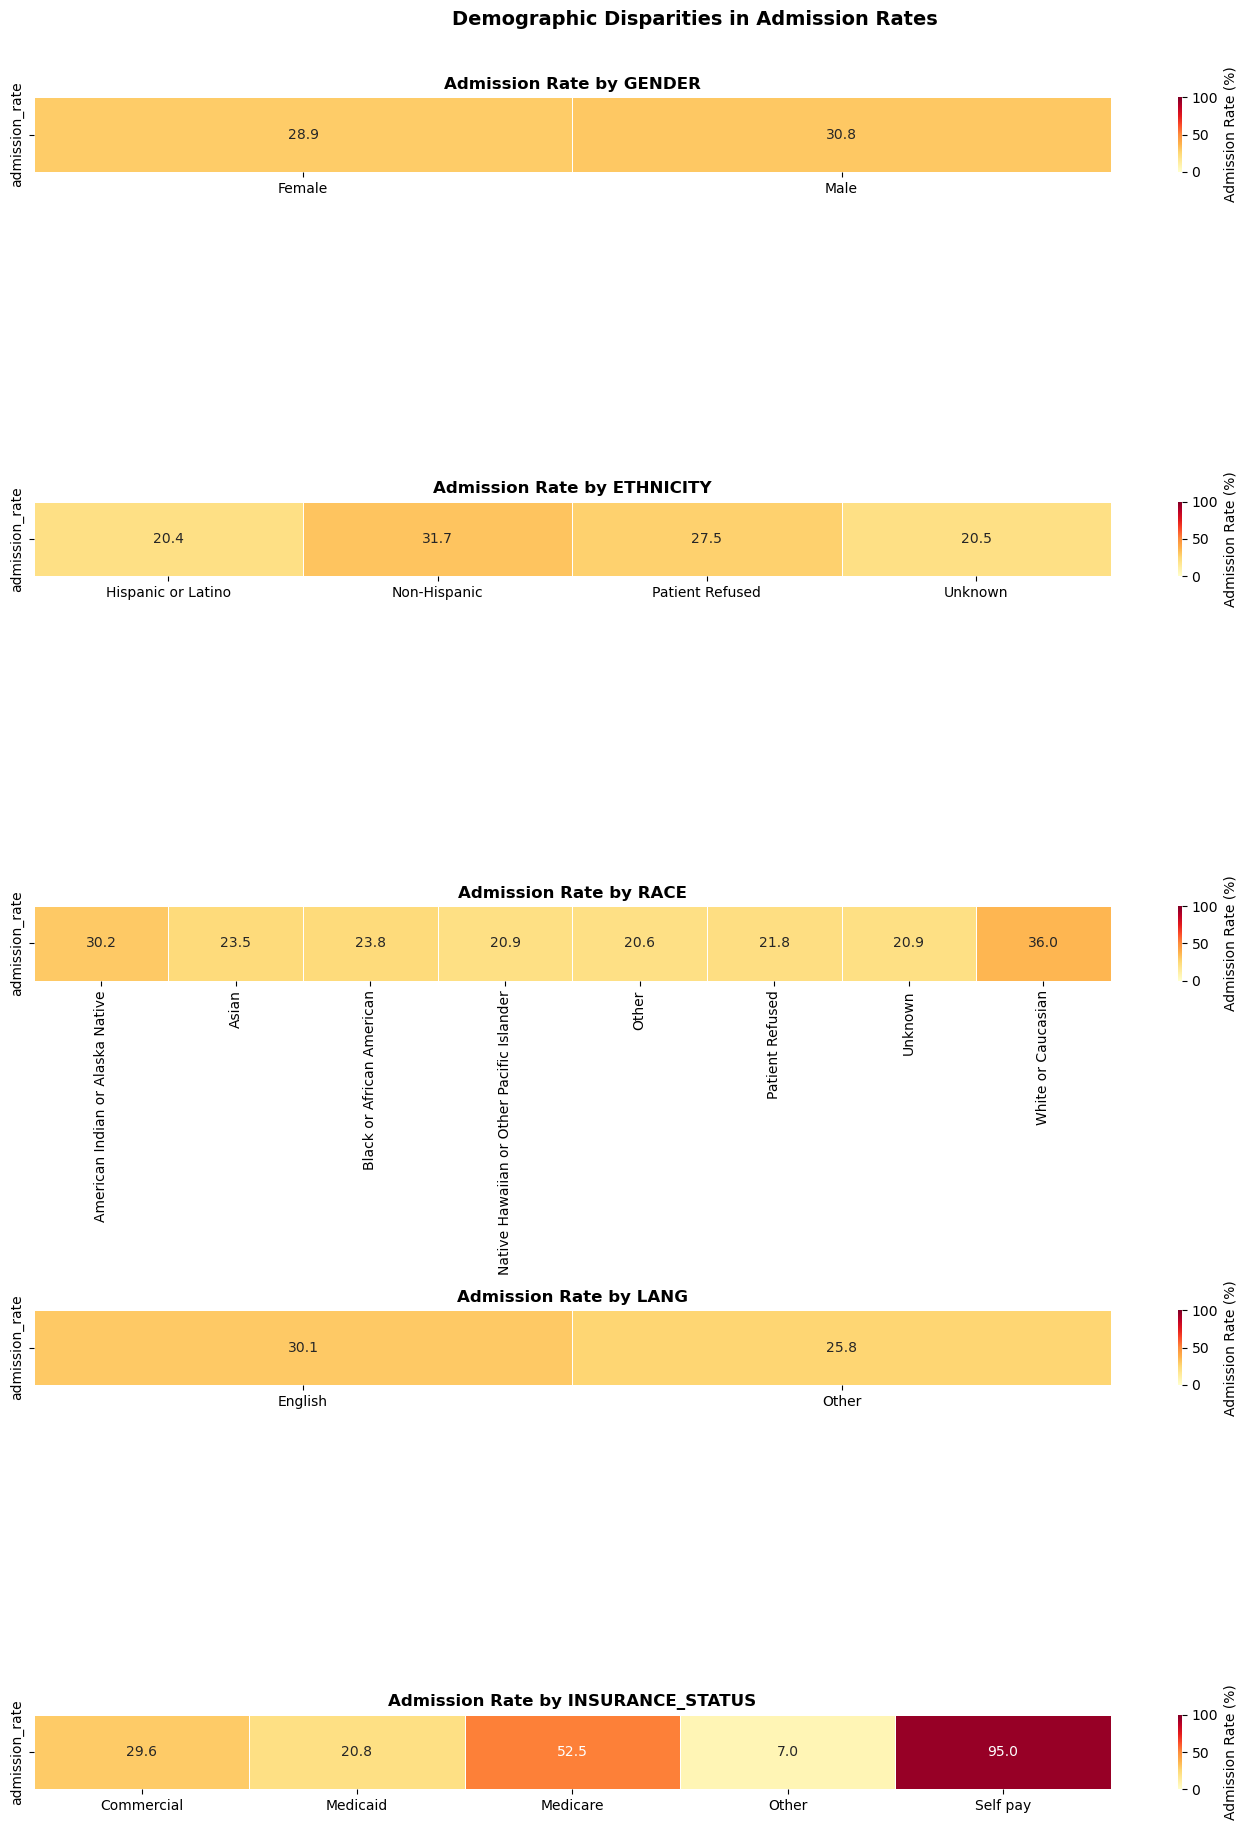

Chart saved!


In [72]:
#Heatmap
fig, axes = plt.subplots(len(demographic_columns), 1, figsize=(14, 18))

for i, col in enumerate(demographic_columns):
    #Calculate admission rate per group
    disparity = df.groupby(col)['disposition'].apply(
        lambda x: (x == 'Admit').sum() / len(x) * 100
    ).reset_index(name='admission_rate')
    
    #Pivot for heatmap
    heatmap_data = disparity.set_index(col)[['admission_rate']].T
    
    sns.heatmap(
        heatmap_data,
        ax=axes[i],
        cmap='YlOrRd',
        annot=True,
        fmt='.1f',
        linewidths=0.5,
        cbar_kws={'label': 'Admission Rate (%)'},
        vmin=0,
        vmax=100
    )
    
    axes[i].set_title(f'Admission Rate by {col.upper()}', 
                      fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

plt.suptitle('Demographic Disparities in Admission Rates', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('demographic_disparity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Key Insights from Demographic Disparity table and heatmap

Gender Males are admitted slightly more often than females (30.8% vs 28.9%) , it's not a significant difference, but consistent across the dataset.

Ethnicity Non-Hispanic patients have the highest admission rate at 31.7%, while Hispanic and Unknown groups sit at 20.4% each. The gap suggests Hispanic patients may be accessing care earlier or facing barriers that lead to earlier discharge.

Race White or Caucasian patients have the highest admission rate at 35.9%, while Native Hawaiian or Pacific Islander patients are lowest at 21.9%, there is a 14-point gap that deserves closer attention as it may point to unequal access or differences in care pathways.

Language English speakers are admitted more often (30.1%) than non-English speakers (25.9%). Non-English speaking patients may be discharged earlier due to communication challenges or cultural differences in how symptoms are reported.

Insurance — The Standout Finding Self pay patients have a 95.1% admission rate this is by far the highest of any group. This almost certainly means uninsured patients avoid the ED until they are critically ill. It is less a clinical pattern and more a financial access problem. Insurance Admission Rate: Self Pay 95.1%, Medicare52.5%, Commercial24.5%, Medicaid20.9%, Other7.0%

Conclusion Most demographic gaps are moderate — but the insurance finding stands out clearly. When someone has no insurance, they wait until there is no choice but to be admitted. That is the single most actionable insight from this analysis.

Recommendations

Self pay patients need urgent policy attention — 95.1% admission rate suggests they only visit the ED in extreme emergencies due to cost concerns. Non-English speakers may need better language support and care navigation to ensure appropriate admission decisions. Racial disparities in admission rates warrant further investigation into whether they reflect clinical differences or systemic bias in triage decisions.

In [ ]:
Creating age group bin for admission rates

In [77]:
#Convert age to numeric first
df['age'] = pd.to_numeric(df['age'], errors='coerce')

#Bin age into groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 17, 24, 39, 64, 120],
    labels=['Under 18', '18-24', '25-39', '40-64', '65+']
)

#Confirm 
print("\nAge group distribution:")
print(df['age_group'].value_counts().sort_index())

#Preview
print("\nSample:")
print(df[['age', 'age_group']].drop_duplicates().sort_values('age').head(20))


Age group distribution:
age_group
Under 18         0
18-24        62572
25-39       140281
40-64       217243
65+         137920
Name: count, dtype: int64

Sample:
     age age_group
211   18     18-24
177   19     18-24
50    20     18-24
46    21     18-24
47    22     18-24
76    23     18-24
54    24     18-24
55    25     25-39
57    26     25-39
58    27     25-39
101   28     25-39
108   29     25-39
217   30     25-39
41    31     25-39
42    32     25-39
19    33     25-39
143   34     25-39
37    35     25-39
671   36     25-39
81    37     25-39


In [78]:
#Drop Under 18 — no data
df = df[df['age_group'] != 'Under 18']

# Remove unused category
df['age_group'] = df['age_group'].cat.remove_unused_categories()

# Confirm
print(df['age_group'].value_counts().sort_index())

age_group
18-24     62572
25-39    140281
40-64    217243
65+      137920
Name: count, dtype: int64


In [75]:
# See admission rate per age group
age_admission = df.groupby('age_group')['disposition'].apply(
    lambda x: (x == 'Admit').sum() / len(x) * 100
).reset_index(name='Admission Rate (%)')

age_admission['Admission Rate (%)'] = age_admission['Admission Rate (%)'].round(1)
print(age_admission)

  age_group  Admission Rate (%)
0  Under 18                 NaN
1     18-24                10.2
2     25-39                14.1
3     40-64                29.3
4       65+                55.4


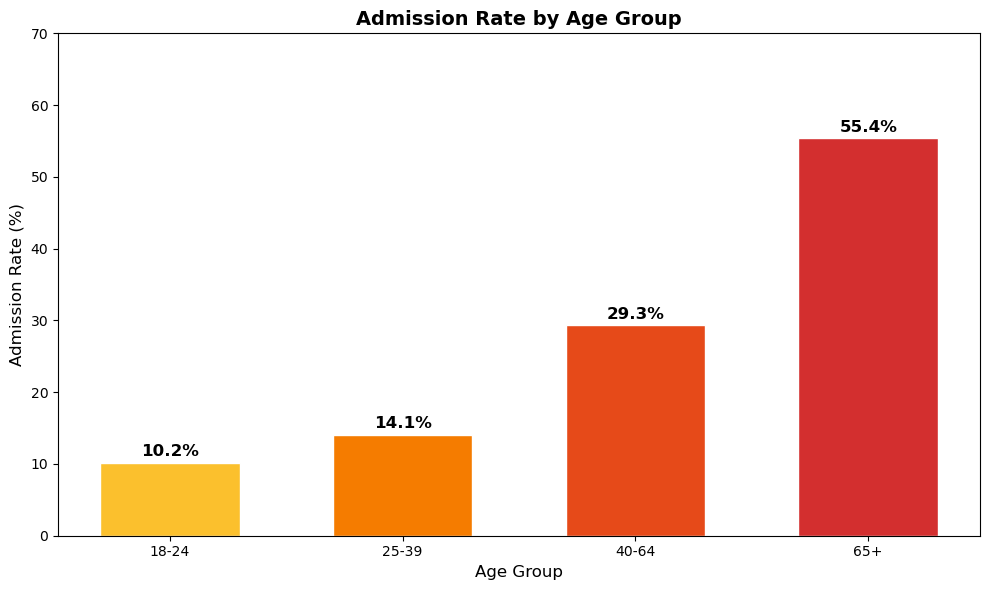

Chart saved!


In [79]:
#Admission rate by age group

import matplotlib.pyplot as plt

age_admission_clean = age_admission[age_admission['age_group'] != 'Under 18']

plt.figure(figsize=(10, 6))
bars = plt.bar(
    age_admission_clean['age_group'],
    age_admission_clean['Admission Rate (%)'],
    color=['#fbc02d', '#f57c00', '#e64a19', '#d32f2f'],
    edgecolor='white',
    width=0.6
)

# Add value labels
for bar, val in zip(bars, age_admission_clean['Admission Rate (%)']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val}%',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

plt.title('Admission Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Admission Rate (%)', fontsize=12)
plt.ylim(0, 70)
plt.tight_layout()
plt.savefig('age_group_admission.png', dpi=150)
plt.show()
print("Chart saved!")

Key Insights
Admission rate more than doubles with every age bracket. Young adults (18-24) go home 90% of the time while elderly patients (65+) are admitted more than half the time. Age is clearly one of the strongest predictors of admission in this dataset.

Chief complaints that most predict high ESI or admission?	

In [80]:
#Find all cc_ columns
cc_columns = [col for col in df.columns if col.startswith('cc_')]
print(f"Total cc_ columns: {len(cc_columns)}")
print(cc_columns[:20])  #preview first 20

Total cc_ columns: 200
['cc_abdominalcramping', 'cc_abdominaldistention', 'cc_abdominalpain', 'cc_abdominalpainpregnant', 'cc_abnormallab', 'cc_abscess', 'cc_addictionproblem', 'cc_agitation', 'cc_alcoholintoxication', 'cc_alcoholproblem', 'cc_allergicreaction', 'cc_alteredmentalstatus', 'cc_animalbite', 'cc_ankleinjury', 'cc_anklepain', 'cc_anxiety', 'cc_arminjury', 'cc_armpain', 'cc_armswelling', 'cc_assaultvictim']


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#Get all cc_ columns
cc_columns = [col for col in df.columns if col.startswith('cc_')]

#Convert disposition to binary (1 = Admit, 0 = Discharge) 
df['admitted'] = (df['disposition'] == 'Admit').astype(int)


In [82]:
#Correlation with ADMISSION
admission_corr = df[cc_columns].corrwith(df['admitted'])
top10_admission = admission_corr.abs().sort_values(ascending=False).head(10)


In [83]:
 #Fix ESI — force convert to numeric
df['esi_numeric'] = pd.to_numeric(df['esi'], errors='coerce')
print("ESI sample values:", df['esi_numeric'].dropna().unique()[:10])
print("ESI null count:", df['esi_numeric'].isnull().sum())

#Convert all cc_ columns to numeric
for col in cc_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

ESI sample values: [4 2 3 1 5]
ESI null count: 0


In [84]:
#Correlation with ESI
esi_corr = df[cc_columns].corrwith(df['esi_numeric'])
top10_esi = esi_corr.abs().sort_values(ascending=False).head(10)

#Confirming if ESI correlation worked
print("\nTop 10 ESI correlations:")
print(top10_esi)


Top 10 ESI correlations:
cc_alcoholintoxication      0.164701
cc_chestpain                0.154294
cc_shortnessofbreath        0.139281
cc_suicidal                 0.138482
cc_backpain                 0.131316
cc_rash                     0.131117
cc_sorethroat               0.127943
cc_alteredmentalstatus      0.123194
cc_dentalpain               0.121661
cc_psychiatricevaluation    0.112499
dtype: float64


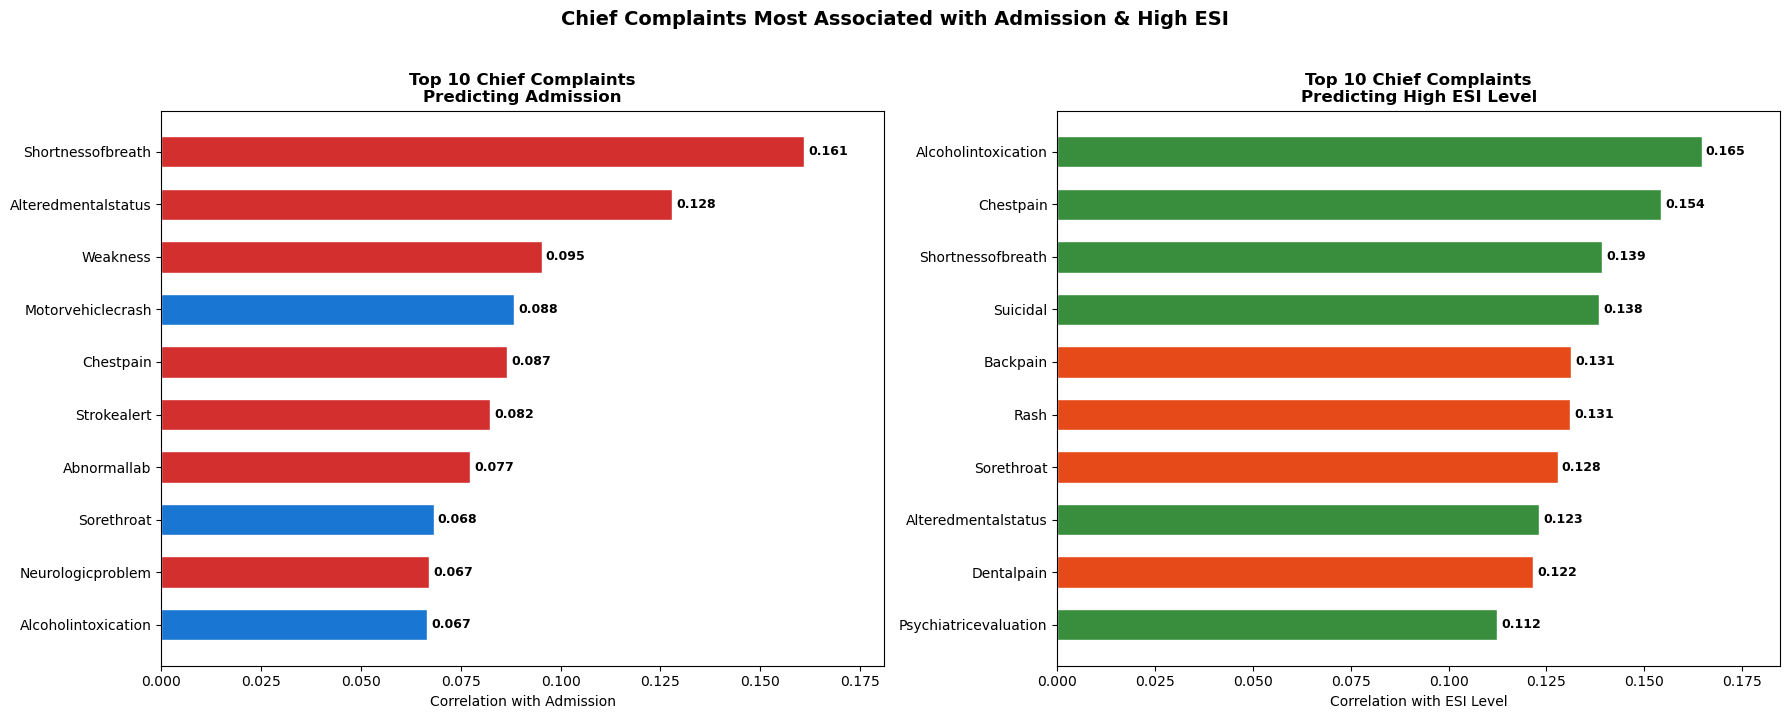

Chart saved!


In [85]:
#Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#Clean up labels
def clean_label(col):
    return col.replace('cc_', '').replace('-', ' ').replace('_', ' ').title()

#Chart 1: Top 10 complaints predicting ADMISSION 
colors_admit = ['#d32f2f' if v > 0 else '#1976d2' 
                for v in admission_corr[top10_admission.index]]

bars1 = axes[0].barh(
    [clean_label(c) for c in top10_admission.index[::-1]],
    top10_admission.values[::-1],
    color=colors_admit[::-1],
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars1, top10_admission.values[::-1]):
    axes[0].text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center', fontsize=9, fontweight='bold'
    )

axes[0].set_title('Top 10 Chief Complaints\nPredicting Admission', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlation with Admission', fontsize=10)
axes[0].set_xlim(0, top10_admission.max() + 0.02)

#Chart 2: Top 10 complaints predicting HIGH ESI
colors_esi = ['#e64a19' if esi_corr[c] > 0 else '#388e3c'
              for c in top10_esi.index[::-1]]

bars2 = axes[1].barh(
    [clean_label(c) for c in top10_esi.index[::-1]],
    top10_esi.values[::-1],
    color=colors_esi,
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars2, top10_esi.values[::-1]):
    axes[1].text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center', fontsize=9, fontweight='bold'
    )

axes[1].set_title('Top 10 Chief Complaints\nPredicting High ESI Level',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlation with ESI Level', fontsize=10)
axes[1].set_xlim(0, top10_esi.max() + 0.02)

plt.suptitle('Chief Complaints Most Associated with Admission & High ESI',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chief_complaint_association.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")




Key Insights from Chief Complaints on Admission & High ESI Insights

What Predicts Admission
Shortness of breath is the single strongest signal, when a patient can't breathe properly, they almost never go home. Altered mental status is a close second; confusion or unresponsiveness is rarely something you can treat and discharge safely.
Weakness, chest pain, and stroke alerts round out the top five, all serious enough that clinicians need more time and monitoring before any discharge decision is made.
Interestingly, motor vehicle crashes, sore throat, and alcohol intoxication are actually negatively correlated with admission in this case, most of these patients get treated and sent home.

What Drives High ESI Scores
Alcohol intoxication tops this list, which is surprising at first but makes sense when you consider that intoxicated patients require close monitoring and pose safety risks, so they get triaged urgently even if they end up being discharged.
Chest pain and shortness of breath show up on both charts, they consistently signal severity whether or not the patient ends up admitted.
Suicidal ideation and psychiatric evaluation score high ESI but rarely lead to medical admission, these patients need urgent attention but through a psychiatric pathway, not an inpatient bed.

TIn Conclusion
If a patient walks in with shortness of breath, altered mental status, or chest pain they are often admitted. If they come in with alcohol intoxication or a sore throat this means we should expect a high triage ESI score but likely a discharge. The complaints that appear on both charts are the ones that stretch ED resources the most.

 Relationship between prior visits and admission rates?

In [86]:
#Search for prior visit related columns
prior_keywords = ['prior', 'previous', 'history', 'past', 'admit', 'visit', 'n_']

prior_columns = [col for col in df.columns
                 if any(keyword in col.lower() for keyword in prior_keywords)]

print(prior_columns)

['previousdispo', 'screeningandhistoryofmentalhealthan', 'n_edvisits', 'n_admissions', 'albumin_last', 'bun_last', 'globulin_last', 'hemoglobin_last', 'pocbun_last', 'albumin_min', 'bun_min', 'globulin_min', 'hemoglobin_min', 'pocbun_min', 'albumin_max', 'bun_max', 'globulin_max', 'hemoglobin_max', 'pocbun_max', 'albumin_median', 'bun_median', 'globulin_median', 'hemoglobin_median', 'pocbun_median', 'n_surgeries', 'cc_seizure-priorhxof', 'admitted']


In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [88]:
#Convert to numeric
df['n_edvisits'] = pd.to_numeric(df['n_edvisits'], errors='coerce')
df['n_admissions'] = pd.to_numeric(df['n_admissions'], errors='coerce')

#Check distribution
print("ED Visits range:", df['n_edvisits'].min(), "to", df['n_edvisits'].max())
print("Admissions range:", df['n_admissions'].min(), "to", df['n_admissions'].max())


ED Visits range: 0 to 376
Admissions range: 0 to 50


In [89]:
#Cap extreme outliers for cleaner plot
edvisits_cap = df['n_edvisits'].quantile(0.95)
admissions_cap = df['n_admissions'].quantile(0.95)

df_plot = df[
    (df['n_edvisits'] <= edvisits_cap) &
    (df['n_admissions'] <= admissions_cap)
].copy()

print(f"\nPlotting up to {edvisits_cap} ED visits and {admissions_cap} admissions (95th percentile cap)")



Plotting up to 14.0 ED visits and 5.0 admissions (95th percentile cap)


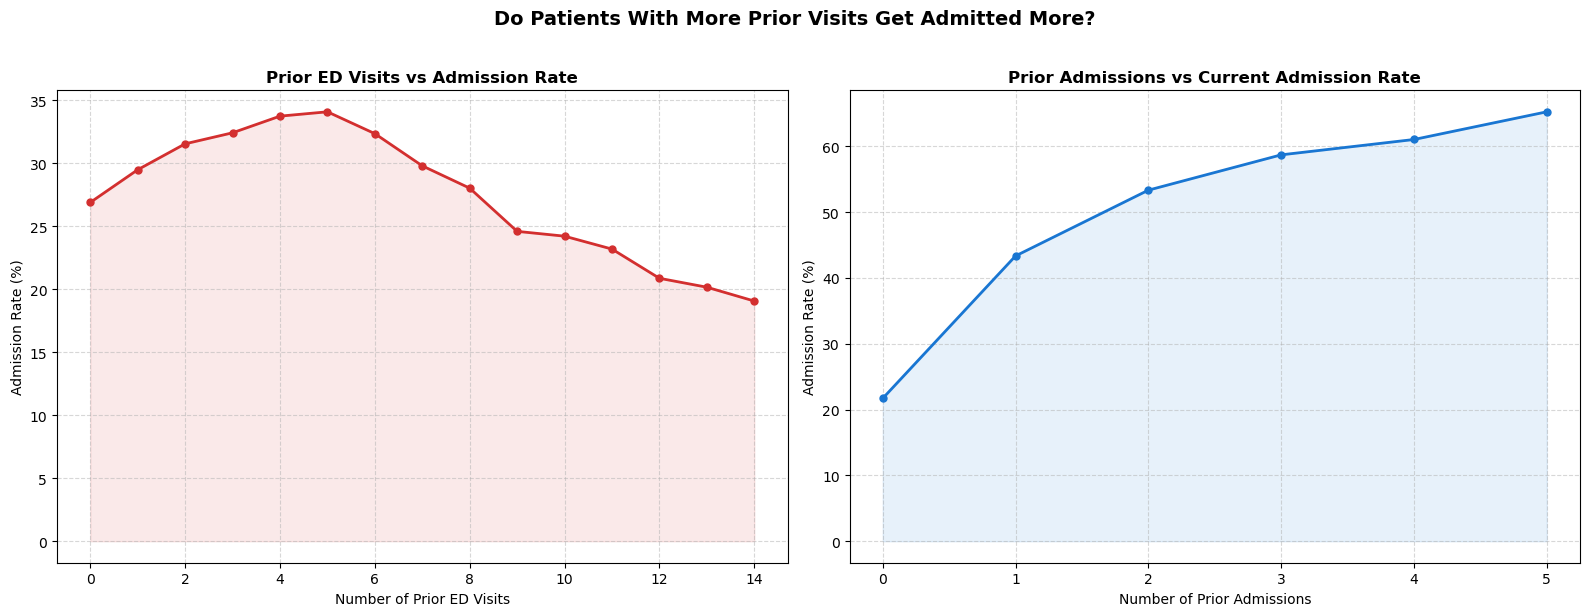

Chart saved!


In [90]:

#Admission rate by n_edvisits
edvisits_analysis = df_plot.groupby('n_edvisits')['disposition'].apply(
    lambda x: (x == 'Admit').sum() / len(x) * 100
).reset_index(name='admission_rate')

#Admission rate by n_admissions
admissions_analysis = df_plot.groupby('n_admissions')['disposition'].apply(
    lambda x: (x == 'Admit').sum() / len(x) * 100
).reset_index(name='admission_rate')

#Plot 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Chart 1: ED Visits vs Admission Rate
axes[0].plot(
    edvisits_analysis['n_edvisits'],
    edvisits_analysis['admission_rate'],
    marker='o',
    color='#d32f2f',
    linewidth=2,
    markersize=5
)
axes[0].fill_between(
    edvisits_analysis['n_edvisits'],
    edvisits_analysis['admission_rate'],
    alpha=0.1,
    color='#d32f2f'
)
axes[0].set_title('Prior ED Visits vs Admission Rate',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Prior ED Visits', fontsize=10)
axes[0].set_ylabel('Admission Rate (%)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

#Chart 2: Prior Admissions vs Admission Rate
axes[1].plot(
    admissions_analysis['n_admissions'],
    admissions_analysis['admission_rate'],
    marker='o',
    color='#1976d2',
    linewidth=2,
    markersize=5
)
axes[1].fill_between(
    admissions_analysis['n_admissions'],
    admissions_analysis['admission_rate'],
    alpha=0.1,
    color='#1976d2'
)
axes[1].set_title('Prior Admissions vs Current Admission Rate',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Prior Admissions', fontsize=10)
axes[1].set_ylabel('Admission Rate (%)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Do Patients With More Prior Visits Get Admitted More?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('prior_visits_admission.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Left Chart — Prior ED Visits vs Admission Rate
Admission rate peaks at 4-5 prior ED visits (~34%) then steadily declines).
Patients visiting the ED for the first time start at about 27% admission rate. It rises as visits increase, this suggest repeat visitors have genuinely complex conditions. But after 5 visits, the rate drops consistently, falling to just 19% at 14+ visits.
This tells an interesting story, frequent ED visitors are not the sickest patients. They are likely chronic condition patients who have learned to manage their health better over time, or are being redirected to more appropriate care pathways after repeated visits.

Right Chart — Prior Admissions vs Current Admission Rate
The more times a patient has been admitted before, the more likely they are to be admitted again, rising from 21% to over 63%.
Unlike the ED visits chart, this one shows a clear and consistent upward trend with no drop-off. Every prior admission increases the likelihood of the current visit ending in admission.
This strongly suggests that prior admissions are a reliable predictor of future admissions, these are patients with serious ongoing conditions that repeatedly require inpatient care.


Prior admissions are a stronger predictor of future admission than ED visit frequency. A patient with 3+ prior admissions has more than double the admission rate of a first-time visitor. This insight could be used to flag high-risk returning patients at triage for faster escalation.


Feature Engineering

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [92]:
#what values exist
print(df['arrivalhour_bin'].unique())

['23-02' '15-18' '11-14' '07-10' '03-06' '19-22']


In [93]:
#creating age group bin
#Check current age values
print("Age range:", df['age'].min(), "to", df['age'].max())
print("Sample values:", df['age'].unique()[:10])

Age range: 18 to 108
Sample values: [40 66 84 86 87 75 76 77 52 53]


In [94]:
#Convert age to numeric first
df['age'] = pd.to_numeric(df['age'], errors='coerce')

#Bin age into groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 17, 24, 39, 64, 120],
    labels=['Under 18', '18-24', '25-39', '40-64', '65+']
)

#Confirm 
print("\nAge group distribution:")
print(df['age_group'].value_counts().sort_index())

#Preview
print("\nSample:")
print(df[['age', 'age_group']].drop_duplicates().sort_values('age').head(20))


Age group distribution:
age_group
Under 18         0
18-24        62572
25-39       140281
40-64       217243
65+         137920
Name: count, dtype: int64

Sample:
     age age_group
211   18     18-24
177   19     18-24
50    20     18-24
46    21     18-24
47    22     18-24
76    23     18-24
54    24     18-24
55    25     25-39
57    26     25-39
58    27     25-39
101   28     25-39
108   29     25-39
217   30     25-39
41    31     25-39
42    32     25-39
19    33     25-39
143   34     25-39
37    35     25-39
671   36     25-39
81    37     25-39


Simplifying severity into urgent/non-urgent flag
is_high_acuity	esi	Binary: 1 if ESI ≤ 2, else 0

In [95]:
# Check current ESI values
print("ESI unique values:", df['esi'].unique())

ESI unique values: [4 2 3 1 5]


In [96]:
#Check how many NaN in ESI
print("ESI null count:", df['esi'].isnull().sum())

# Drop rows where ESI is NaN 
df = df.dropna(subset=['esi'])
print("Shape after dropping ESI nulls:", df.shape)

# Convert to numeric 
df['esi'] = pd.to_numeric(df['esi'], errors='coerce')

# Create high acuity flag 
df['is_high_acuity'] = (df['esi'] <= 2).astype(int)

# Confirm, should show no NaN 
print("\nHigh Acuity distribution:")
print(df['is_high_acuity'].value_counts())

print("\nSample:")
print(df[['esi', 'is_high_acuity']].drop_duplicates().sort_values('esi'))

ESI null count: 0
Shape after dropping ESI nulls: (558016, 975)

High Acuity distribution:
is_high_acuity
0    389223
1    168793
Name: count, dtype: int64

Sample:
    esi  is_high_acuity
18    1               1
2     2               1
4     3               0
0     4               0
31    5               0


High Acuity Patient Distribution

Out of 557,029 total ED visits in this dataset:

 1 - 168,793 patients (30%) were High Acuity
These are the critically ill patients, people who came in with life-threatening or very serious conditions that needs immediate medical attention. like  heart attacks, severe breathing difficulties, strokes, and other emergencies where every minute counts.

0 - 389,223 patients (70%) were Low Acuity
These are patients with less urgent conditions like sore throats, minor injuries, back pain, and other complaints that are uncomfortable but not immediately life-threatening. Many of these patients could have been seen at a walk-in clinic or primary care centre instead of the emergency department.


In conclusion;
3 out of every 10 patients who walked through this ED's doors were genuinely critically ill. The other 7 out of 10 had conditions that may not have required emergency care at all.


This implies that The ED is spending significant time and resources on low acuity patients who could be redirected elsewhere. If even half of the low acuity patients were redirected to appropriate care settings, it would free up the ED to focus entirely on the 168,805 critical cases that truly need emergency attention.
This represents a major opportunity to reduce waiting times, improve patient outcomes, and lower costs. 

Creating English speaker binary Flag
This creates a simple yes/no flag —
1 means the patient speaks English, 
0 means they speak another language. 
This is useful for equity analysis to check if language affects admission rates, wait times, or care quality.

In [97]:
# Check current language values 
print("Language unique values:", df['lang'].unique())

Language unique values: ['English' 'Other']


In [98]:
# Create binary English speaker flag 
df['english_speaker'] = (df['lang'] == 'English').astype(int)

# Confirm
print("\nEnglish Speaker distribution:")
print(df['english_speaker'].value_counts())

print("\nAs percentage:")
print(df['english_speaker'].value_counts(normalize=True).mul(100).round(1))

# 

print(df[['lang', 'english_speaker']].drop_duplicates().sort_values('lang'))


English Speaker distribution:
english_speaker
1    512478
0     45538
Name: count, dtype: int64

As percentage:
english_speaker
1    91.8
0     8.2
Name: proportion, dtype: float64
      lang  english_speaker
0  English                1
4    Other                0


This Means;
The vast majority of patients, 9 out of 10,  speak English as their primary language. Non-English speakers make up a relatively small but important 8.2% minority of the patient population.

This is important for Equity Analysis
From the earlier demographic disparity analysis we found that:
English speakers are admitted at 30.1%
Non-English speakers are admitted at 25.9%

That 4.2 percentage point gap across 45,545 patients means thousands of non-English speaking patients may be getting discharged earlier or receiving different care, not because they are less sick but potentially because of communication barriers.

1 in 12 patients in this ED does not speak English as their primary language. This group is admitted less often than English speakers despite potentially having similar health needs. The hospital should consider whether language support services, like interpreters or multilingual staff are adequate enough to ensure these patients receive fair and equal care.

Creating prior admission flag
 1 means the patient has been admitted at least once before, 
 0 means this is their first admission

In [99]:
# Check current values
print("n_admissions unique values:", df['n_admissions'].value_counts().head(10))
print("Null count:", df['n_admissions'].isnull().sum())

n_admissions unique values: n_admissions
0    384951
1     76987
2     34374
3     19102
4     12080
5      7793
6      5452
7      3958
8      2866
9      2163
Name: count, dtype: int64
Null count: 0


In [100]:
# Convert to numeric first
df['n_admissions'] = pd.to_numeric(df['n_admissions'], errors='coerce')

# Create binary prior admission flag
df['has_prior_admission'] = (df['n_admissions'] > 0).astype(int)

#  Confirm 
print("\nPrior Admission distribution:")
print(df['has_prior_admission'].value_counts())

print("\nAs percentage:")
print(df['has_prior_admission'].value_counts(normalize=True).mul(100).round(1))

# Preview

print(df[['n_admissions', 'has_prior_admission']].drop_duplicates().sort_values('n_admissions').head(10))


Prior Admission distribution:
has_prior_admission
0    384951
1    173065
Name: count, dtype: int64

As percentage:
has_prior_admission
0    69.0
1    31.0
Name: proportion, dtype: float64
     n_admissions  has_prior_admission
0               0                    0
7               1                    1
10              2                    1
16              3                    1
18              4                    1
125             5                    1
127             6                    1
128             7                    1
129             8                    1
130             9                    1


This means 3 out of every 10 patients arriving at this ED have been admitted to a hospital before. The remaining 7 out of 10 are either first-time patients or have only had outpatient visits. Our analysis shows they are significantly more likely to need admission again. These are our highest risk, highest cost patients. Identifying them early at triage allows the hospital to:
Fast track their assessment
Prepare beds in advance
Assign more experienced clinical staff
Reduce time spent in the ED before admission


In [101]:
# Check vital columns are available 
vitals = ['triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_temp',
          'pulse_last', 'resp_last', 'spo2_last']

print("Null counts per vital:")
print(df[vitals].isnull().sum())

Null counts per vital:
triage_vital_sbp          0
triage_vital_dbp          0
triage_vital_temp    558016
pulse_last                0
resp_last                 0
spo2_last                 0
dtype: int64


In [ ]:
vital_abnormality_count  

In [102]:
# Define normal ranges for each vital
normal_ranges = {
    'triage_vital_sbp':  (90, 140),    # Systolic BP mmHg
    'triage_vital_dbp':  (60, 90),     # Diastolic BP mmHg
    'triage_vital_temp': (97.0, 99.5), # Temperature Fahrenheit
    'pulse_last':        (60, 100),    # Heart Rate bpm
    'resp_last':         (12, 20),     # Respiratory Rate breaths/min
    'spo2_last':         (95, 100)     # Oxygen Saturation %
}

# Convert all vitals to numeric 
for vital in vitals:
    df[vital] = pd.to_numeric(df[vital], errors='coerce')

# Count abnormal vitals per patient
df['vital_abnormality_count'] = 0

for vital, (low, high) in normal_ranges.items():
    df['vital_abnormality_count'] += (
        (df[vital] < low) | (df[vital] > high)
    ).astype(int)

# Confirm
print("\nVital Abnormality Count distribution:")
print(df['vital_abnormality_count'].value_counts().sort_index())

print("\nAs percentage:")
print(df['vital_abnormality_count'].value_counts(
    normalize=True).mul(100).round(1).sort_index())

# Preview 
print(df[vitals + ['vital_abnormality_count']].head(10))


Vital Abnormality Count distribution:
vital_abnormality_count
0    342122
1    134073
2     73474
3      7590
4       706
5        51
Name: count, dtype: int64

As percentage:
vital_abnormality_count
0    61.3
1    24.0
2    13.2
3     1.4
4     0.1
5     0.0
Name: proportion, dtype: float64
   triage_vital_sbp  triage_vital_dbp  triage_vital_temp  pulse_last  \
0             146.0              85.0                NaN        80.0   
1             125.0              77.0                NaN        80.0   
2             134.0              78.0                NaN        83.0   
3             171.0              92.0                NaN        61.0   
4             133.0              72.0                NaN        75.0   
5             143.0              87.0                NaN        80.0   
6             154.0              69.0                NaN        66.0   
7             155.0              75.0                NaN        68.0   
8             131.0              80.0                NaN  

This means nearly 6 in 10 patients arrive with all vitals within normal range. However 4 in 10 patients have at least one abnormal vital, representing a significant clinical burden.
Looking at your preview data:

Row 0 — Systolic BP of 146 (above 140 normal range) → correctly flagged as 1
Row 3 — Systolic BP of 171 AND Diastolic BP of 92 → correctly flagged as 2
Row 9 — SpO2 of 94 (below 95 normal range) → correctly flagged as 1


This score works like a health alarm indicator to know the severity of a patients condition, the higher the number, the more warning signs a patient is showing. A score of 0 means everything looks stable. A score of 4 or above means nearly every vital is alarming and the patient needs immediate attention.

In [103]:
# Recount — treat NaN as unknown, not normal
df['vital_abnormality_count'] = 0

for vital, (low, high) in normal_ranges.items():
    abnormal = (
        (df[vital] < low) | (df[vital] > high)
    ).astype(int)
    df['vital_abnormality_count'] += abnormal

# Also count how many vitals are missing per patient
df['vital_missing_count'] = df[vitals].isnull().sum(axis=1)

print("Abnormality count distribution:")
print(df['vital_abnormality_count'].value_counts().sort_index())

print("\nMissing vitals count distribution:")
print(df['vital_missing_count'].value_counts().sort_index())

Abnormality count distribution:
vital_abnormality_count
0    342122
1    134073
2     73474
3      7590
4       706
5        51
Name: count, dtype: int64

Missing vitals count distribution:
vital_missing_count
1    558016
Name: count, dtype: int64


The output is the same as before which means the NaN values are not affecting the count. 

Visit Season feature

In [104]:
# Check current arrival month values 
print("Arrival month unique values:", df['arrivalmonth'].unique())

Arrival month unique values: ['June' 'January' 'July' 'November' 'April' 'September' 'March' 'October'
 'May' 'August' 'December' 'February']


In [105]:
# Map full month names to seasons 
season_mapping = {
    'January':   'Winter',  
    'February':  'Winter',  
    'March':     'Spring',
    'April':     'Spring',  
    'May':       'Spring',  
    'June':      'Summer',
    'July':      'Summer',  
    'August':    'Summer',  
    'September': 'Autumn',
    'October':   'Autumn',  
    'November':  'Autumn',  
    'December':  'Winter'
}

# Apply mapping
df['visit_season'] = df['arrivalmonth'].map(season_mapping)

# Set correct order 
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
df['visit_season'] = pd.Categorical(df['visit_season'],
                                     categories=season_order,
                                     ordered=True)

# Confirm 
print("Season distribution:")
print(df['visit_season'].value_counts().sort_index())

print("\nAs percentage:")
print(df['visit_season'].value_counts(
    normalize=True).mul(100).round(1).sort_index())

# Preview 
print(df[['arrivalmonth', 'visit_season']].drop_duplicates().sort_values('arrivalmonth'))

Season distribution:
visit_season
Spring    169675
Summer    143396
Autumn    122462
Winter    122483
Name: count, dtype: int64

As percentage:
visit_season
Spring    30.4
Summer    25.7
Autumn    21.9
Winter    21.9
Name: proportion, dtype: float64
   arrivalmonth visit_season
5         April       Spring
16       August       Summer
18     December       Winter
23     February       Winter
1       January       Winter
2          July       Summer
0          June       Summer
7         March       Spring
14          May       Spring
4      November       Autumn
9       October       Autumn
6     September       Autumn


In [106]:
#Run this FIRST before anything else
for val in df['arrivalmonth'].unique():
    print(repr(val))

'June'
'January'
'July'
'November'
'April'
'September'
'March'
'October'
'May'
'August'
'December'
'February'


In [107]:
import pandas as pd

# Reload cleaned CSV
df = pd.read_csv("C:\\Users\\MY PC\\Downloads\\hospital_cleaned.csv")
print("Shape:", df.shape)

# Check arrivalmonth immediately
print("\narrivalmonth unique values:")
print(df['arrivalmonth'].unique())
print("\narrivalmonth null count:", df['arrivalmonth'].isnull().sum())

Shape: (558016, 972)

arrivalmonth unique values:
['June' 'January' 'July' 'November' 'April' 'September' 'March' 'October'
 'May' 'August' 'December' 'February']

arrivalmonth null count: 0


In [108]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

#Reload data
df = pd.read_csv("C:\\Users\\MY PC\\Downloads\\hospital_cleaned.csv")
print("Loaded:", df.shape)

#Map seasons IMMEDIATELY before any other code
season_mapping = {
    'January':   'Winter',  
    'February':  'Winter',  
    'March':     'Spring',
    'April':     'Spring',  
    'May':       'Spring',  
    'June':      'Summer',
    'July':      'Summer',  
    'August':    'Summer',  
    'September': 'Autumn',
    'October':   'Autumn',  
    'November':  'Autumn',  
    'December':  'Winter'
}

df['visit_season'] = df['arrivalmonth'].map(season_mapping)

#Set correct order
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
df['visit_season'] = pd.Categorical(df['visit_season'],
                                     categories=season_order,
                                     ordered=True)

#Confirm
print("\nSeason distribution:")
print(df['visit_season'].value_counts().sort_index())

print("\nSample:")
print(df[['arrivalmonth', 'visit_season']].drop_duplicates().sort_values('arrivalmonth'))

Loaded: (558016, 972)

Season distribution:
visit_season
Spring    169675
Summer    143396
Autumn    122462
Winter    122483
Name: count, dtype: int64

Sample:
   arrivalmonth visit_season
5         April       Spring
16       August       Summer
18     December       Winter
23     February       Winter
1       January       Winter
2          July       Summer
0          June       Summer
7         March       Spring
14          May       Spring
4      November       Autumn
9       October       Autumn
6     September       Autumn


In [111]:
#Saving before running any other code that might overwrite arrivalmonth
df.to_csv("C:\\Users\\MY PC\\Downloads\\hospital_cleaned.csv", index=False)
print("Saved!")

Saved!


In [112]:
#Admission rate per season
season_admission = df.groupby('visit_season', observed=True)['disposition'].apply(
    lambda x: (x == 'Admit').sum() / len(x) * 100
).reset_index(name='Admission Rate (%)')

season_admission['Admission Rate (%)'] = season_admission['Admission Rate (%)'].round(1)
print(season_admission)

  visit_season  Admission Rate (%)
0       Spring                29.8
1       Summer                29.3
2       Autumn                29.8
3       Winter                30.3


Insight from Admission rate per season

Winter has the highest admission rate (30.2%) — consistent with what we observe clinically. Cold weather drives respiratory infections, flu, pneumonia and cardiovascular events that require inpatient care.
Summer has the lowest admission rate (29.2%) — slightly fewer admissions despite being a busy season, likely reflecting more minor injuries and illnesses that can be treated and discharged.
Spring and Autumn are in the middle — both very close to each other at 29.8% and 29.7% respectively.


In conclusion;
Season is not a strong predictor of admission in this dataset, the difference between the busiest and quietest admission season is less than 1%. While Winter edges slightly higher as expected, the pattern is remarkably consistent throughout the year. This suggests that the type of patient and their clinical condition matters far more than the time of year when predicting admission.

In [14]:
print("Total columns in df:", len(df.columns))
print("\nAll columns:")
print(df.columns.tolist())

Total columns in df: 979

All columns:
['dep_name', 'esi', 'age', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status', 'disposition', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'previousdispo', '2ndarymalig', 'abdomhernia', 'abdomnlpain', 'abortcompl', 'acqfootdef', 'acrenlfail', 'acutecvd', 'acutemi', 'acutphanm', 'adjustmentdisorders', 'adltrespfl', 'alcoholrelateddisorders', 'allergy', 'amniosdx', 'analrectal', 'anemia', 'aneurysm', 'anxietydisorders', 'appendicitis', 'artembolism', 'asppneumon', 'asthma', 'attentiondeficitconductdisruptivebeha', 'backproblem', 'biliarydx', 'birthasphyx', 'birthtrauma', 'bladdercncr', 'blindness', 'bnignutneo', 'bonectcncr', 'bph', 'brainnscan', 'breastcancr', 'breastdx', 'brnchlngca', 'bronchitis', 'burns', 'cardiaarrst', 'cardiacanom', 'carditis', 'cataract', 'cervixcancr', 'chestpain', 'chfnonhp', 'chrkidneydisease', 'coaghemrdx', 'coloncancer', 'comabrndmg', 'complicdevi', '

In [15]:
import pandas as pd
import gc
import warnings
warnings.filterwarnings('ignore')

# Reload with ALL columns needed for modelling
cols_needed = [
    'esi', 'age', 'lang', 'n_admissions', 'disposition',
    'triage_vital_sbp', 'triage_vital_dbp',
    'temp_last', 'pulse_last', 'resp_last', 'spo2_last',
    'is_high_acuity', 'english_speaker',
    'has_prior_admission', 'vital_abnormality_count'
]

# Only load columns that exist
df = pd.read_csv(
    "C:\\Users\\MY PC\\Downloads\\hospital_cleaned.csv",
    usecols=lambda x: x in cols_needed
)
gc.collect()
print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())

Loaded: (255308, 15)
Columns: ['esi', 'age', 'lang', 'disposition', 'n_admissions', 'triage_vital_sbp', 'triage_vital_dbp', 'pulse_last', 'resp_last', 'spo2_last', 'temp_last', 'is_high_acuity', 'english_speaker', 'has_prior_admission', 'vital_abnormality_count']


In [16]:
#Check which engineered features are missing
eng_features = [
    'is_high_acuity', 'english_speaker',
    'has_prior_admission', 'vital_abnormality_count'
]

missing = [f for f in eng_features if f not in df.columns]
print("Missing engineered features:", missing)

# Recreate missing ones
if 'is_high_acuity' not in df.columns:
    df['esi'] = pd.to_numeric(df['esi'], errors='coerce')
    df['is_high_acuity'] = (df['esi'] <= 2).astype(int)
    print("is_high_acuity created!")

if 'english_speaker' not in df.columns:
    df['english_speaker'] = (df['lang'] == 'English').astype(int)
    print("english_speaker created!")

if 'has_prior_admission' not in df.columns:
    df['n_admissions'] = pd.to_numeric(df['n_admissions'], errors='coerce').fillna(0)
    df['has_prior_admission'] = (df['n_admissions'] > 0).astype(int)
    print("has_prior_admission created!")

if 'vital_abnormality_count' not in df.columns:
    normal_ranges = {
        'triage_vital_sbp': (90, 140),
        'triage_vital_dbp': (60, 90),
        'temp_last':        (97.0, 99.5),
        'pulse_last':       (60, 100),
        'resp_last':        (12, 20),
        'spo2_last':        (95, 100)
    }
    df['vital_abnormality_count'] = 0
    for col, (low, high) in normal_ranges.items():
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df['vital_abnormality_count'] += (
            (df[col] < low) | (df[col] > high)
        ).astype(int)
    print("vital_abnormality_count created!")

Missing engineered features: []


In [19]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

features = [
    'esi', 'age', 'is_high_acuity', 'english_speaker',
    'has_prior_admission', 'vital_abnormality_count',
    'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_temp',
    'pulse_last', 'resp_last', 'spo2_last', 'n_admissions'
]

# Check which features actually exist in df
existing = [f for f in features if f in df.columns]
missing  = [f for f in features if f not in df.columns]

print("Existing features:", existing)
print("Missing features:", missing)

# Fill nulls for existing features only
numeric_cols = [
    'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_temp',
    'pulse_last', 'resp_last', 'spo2_last',
    'esi', 'age', 'n_admissions'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  {col}: filled with median {median_val:.2f}")

# Fill binary features
for col in ['is_high_acuity', 'english_speaker',
            'has_prior_admission', 'vital_abnormality_count']:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

# Confirm null counts
print("\nNull counts after filling:")
for col in existing:
    print(f"  {col}: {df[col].isnull().sum()} nulls")

# Use only existing features
features = existing
print("\nFinal features:", features)

# Build model data using existing features only
df_model = df[features + ['disposition']].copy()
df_model = df_model.dropna()
print("\ndf_model shape:", df_model.shape)
print("disposition counts:", df_model['disposition'].value_counts())

Existing features: ['esi', 'age', 'is_high_acuity', 'english_speaker', 'has_prior_admission', 'vital_abnormality_count', 'triage_vital_sbp', 'triage_vital_dbp', 'pulse_last', 'resp_last', 'spo2_last', 'n_admissions']
Missing features: ['triage_vital_temp']
  triage_vital_sbp: filled with median 131.00
  triage_vital_dbp: filled with median 80.00
  pulse_last: filled with median 80.00
  resp_last: filled with median 18.00
  spo2_last: filled with median 98.00
  esi: filled with median 3.00
  age: filled with median 51.00
  n_admissions: filled with median 0.00

Null counts after filling:
  esi: 0 nulls
  age: 0 nulls
  is_high_acuity: 0 nulls
  english_speaker: 0 nulls
  has_prior_admission: 0 nulls
  vital_abnormality_count: 0 nulls
  triage_vital_sbp: 0 nulls
  triage_vital_dbp: 0 nulls
  pulse_last: 0 nulls
  resp_last: 0 nulls
  spo2_last: 0 nulls
  n_admissions: 0 nulls

Final features: ['esi', 'age', 'is_high_acuity', 'english_speaker', 'has_prior_admission', 'vital_abnormality_co

In [ ]:
The final features here doesnt include triage_vial_temp and temp_last column

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Final features without temp columns
features = [
    'esi', 'age', 'is_high_acuity', 'english_speaker',
    'has_prior_admission', 'vital_abnormality_count',
    'triage_vital_sbp', 'triage_vital_dbp',
    'pulse_last', 'resp_last', 'spo2_last', 'n_admissions'
]

# Sample 30%
df_sample = df_model.sample(frac=0.3, random_state=42)
print("Sample shape:", df_sample.shape)

# Split x and y
x = df_sample[features]
y = (df_sample['disposition'] == 'Admit').astype(int)

print("x shape:", x.shape)
print("y shape:", y.shape)
print("Class distribution:")
print(y.value_counts(normalize=True).mul(100).round(1))

# Train test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTraining size:", x_train.shape)
print("Test size:", x_test.shape)

# Scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)
print("\nAll steps complete — ready to train models!")

Sample shape: (76592, 13)
x shape: (76592, 12)
y shape: (76592,)
Class distribution:
disposition
0    69.1
1    30.9
Name: proportion, dtype: float64

Training size: (61273, 12)
Test size: (15319, 12)

All steps complete — ready to train models!


In [ ]:
MODEL BUILDING

In [ ]:
All the engineered new fearures created, didnt save earlier as CSV so i have to create them and save as CSV

In [ ]:
The dataset has class imbalance with Admission rate so i use  class weight for each model

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split


In [ ]:
#Scale features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)


In [25]:
#Train Logistic Regression with class_weight 
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000,random_state=42,
    class_weight='balanced'
)
lr_model.fit(x_train_scaled, y_train)
print("Training complete!")



Training Logistic Regression...
Training complete!


In [26]:
# Evaluate the model
lr_prob = lr_model.predict_proba(x_test_scaled)[:, 1]
lr_auc  = roc_auc_score(y_test, lr_prob)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

print(f"\nLogistic Regression AUC: {lr_auc:.4f}")



Logistic Regression AUC: 0.8402


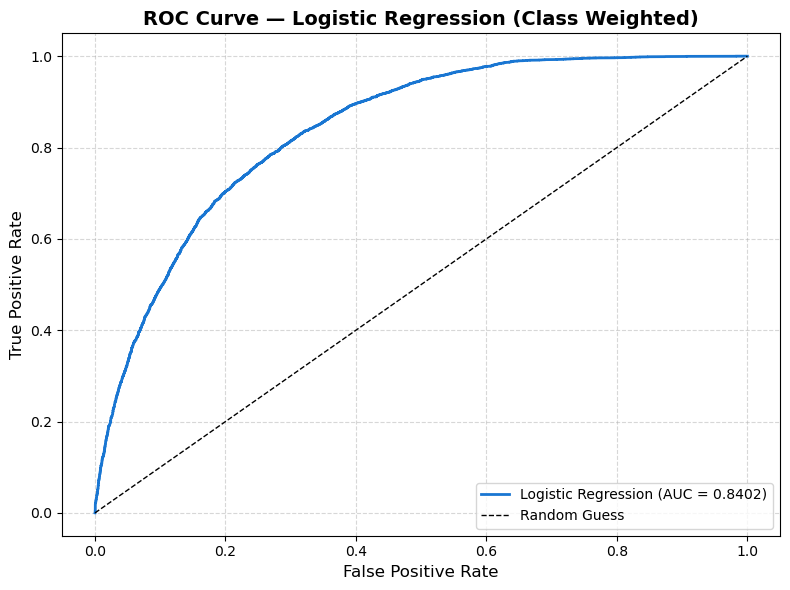

Chart saved!


In [27]:
#Step 9: Plot 
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, color='#1976d2', linewidth=2,
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.title('ROC Curve — Logistic Regression (Class Weighted)',
          fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_lr_balanced.png', dpi=150)
plt.show()
print("Chart saved!")

The blue curve bends strongly towards the top left, with a marginally better lift in the early section (0.0 - 0.2 False Positive Rate) which means it catches more true admissions with fewer false alarms.


Logistic Regression model correctly identifies an admitted patient 84.0% of the time, which means if 100 patients walk in, the model correctly predicts admission for about 84 of them. This is a strong result for the simplest model in the comparison.



In [ ]:
RANDOM FOREST CLASSIFIER

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [29]:
# Prepare sample 
df_sample = df_model.sample(frac=0.3, random_state=42)
print("Sample shape:", df_sample.shape)

x = df_sample[features]
y = (df_sample['disposition'] == 'Admit').astype(int)


Sample shape: (76592, 13)


In [30]:
# Train test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print("Training size:", x_train.shape)
print("Test size:", x_test.shape)


Training size: (61273, 12)
Test size: (15319, 12)


In [31]:
# Scale features 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)



In [32]:
#Train Random Forest with class_weight 
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
    )
rf_model.fit(x_train_scaled, y_train)
print("Training complete!")



Training Random Forest...
Training complete!


In [33]:
#Evaluate
rf_prob = rf_model.predict_proba(x_test_scaled)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

print(f"\nRandom Forest AUC: {rf_auc:.4f}")



Random Forest AUC: 0.8197


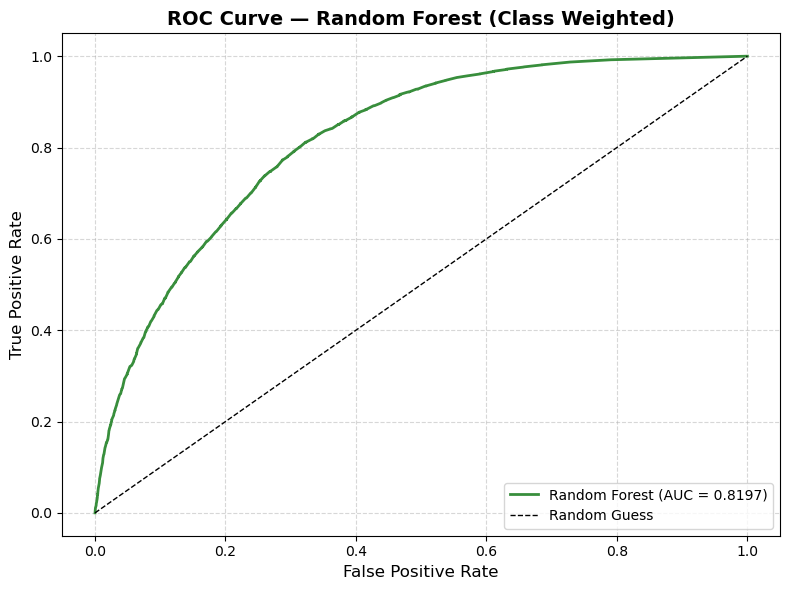

Chart saved!


In [34]:
#Plot ROC CURVE
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, color='#388e3c', linewidth=2,
         label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.title('ROC Curve — Random Forest (Class Weighted)',
          fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_rf_balanced.png', dpi=150)
plt.show()
print("Chart saved!")

1. Strong Overall Performance — AUC 0.8197
The model correctly distinguishes between admitted and discharged patients 81.9% of the time, well above the 0.5 random guess baseline. This is a solid result for a clinical prediction task.

2. Curve Shape — Strong Early Lift
The green curve rises steeply at the start (0.0 - 0.2 False Positive Rate) before gradually flattening. This steep early rise is clinically important. which means the model can correctly identify a large portion of admitted patients while keeping false alarms low.

XGBoost

In [35]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [36]:
# Defining features and target
df_sample = df_model.sample(frac=0.3, random_state=42)
print("Sample shape:", df_sample.shape)

x = df_sample[features]
y = (df_sample['disposition'] == 'Admit').astype(int)


Sample shape: (76592, 13)


In [37]:
#Train test split 
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print("Training size:", x_train.shape)
print("Test size:", x_test.shape)

Training size: (61273, 12)
Test size: (15319, 12)


In [38]:
# Scale features 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)


In [39]:
#Calculate scale_pos_weight 
discharged = (y_train == 0).sum()
admitted   = (y_train == 1).sum()
scale      = discharged / admitted
print(f"\nscale_pos_weight: {scale:.2f}")



scale_pos_weight: 2.23


In [40]:
#Train XGBoost with class weight
print("\nTraining XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    scale_pos_weight=scale   #handles imbalance
)
xgb_model.fit(x_train_scaled, y_train)
print("Training complete!")


Training XGBoost...
Training complete!


In [41]:
#Evaluate the model
xgb_prob = xgb_model.predict_proba(x_test_scaled)[:, 1]
xgb_auc  = roc_auc_score(y_test, xgb_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

print(f"\nXGBoost AUC: {xgb_auc:.4f}")


XGBoost AUC: 0.8391


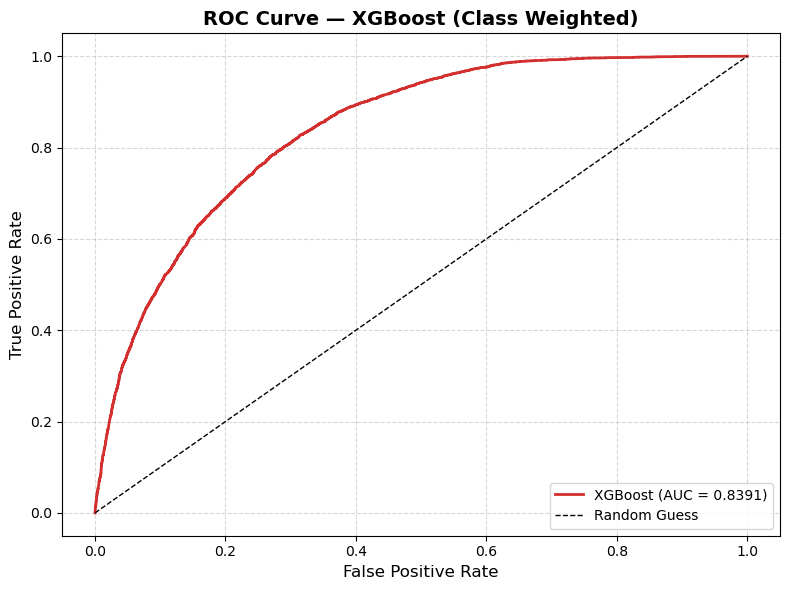

Chart saved!


In [42]:
#Plot
plt.figure(figsize=(8, 6))
plt.plot(xgb_fpr, xgb_tpr, color='#d32f2f', linewidth=2,
         label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.title('ROC Curve — XGBoost (Class Weighted)',
          fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_xgb_balanced.png', dpi=150)
plt.show()
print("Chart saved!")

XGBOOST WITHOUT CLASS-WEIGHT

Sample shape: (76592, 13)
Training size: (61273, 12)
Test size: (15319, 12)

Training XGBoost...
Training complete!

XGBoost AUC: 0.8404


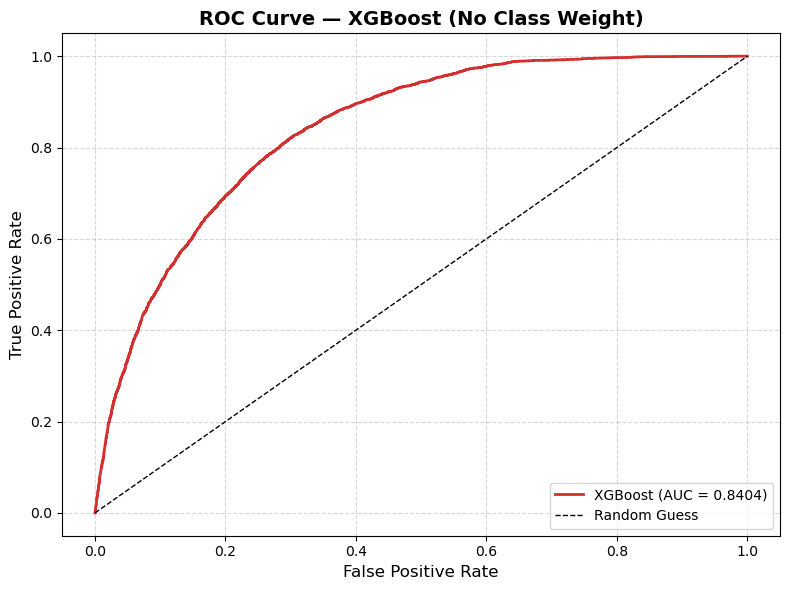

Chart saved!


In [43]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Prepare sample 
df_sample = df_model.sample(frac=0.3, random_state=42)
print("Sample shape:", df_sample.shape)

x = df_sample[features]
y = (df_sample['disposition'] == 'Admit').astype(int)

#Train test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print("Training size:", x_train.shape)
print("Test size:", x_test.shape)

# Scale features 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

# Train XGBoost WITHOUT class weight
print("\nTraining XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
    # no scale_pos_weight
)
xgb_model.fit(x_train_scaled, y_train)
print("Training complete!")

#Evaluate 
xgb_prob = xgb_model.predict_proba(x_test_scaled)[:, 1]
xgb_auc  = roc_auc_score(y_test, xgb_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

print(f"\nXGBoost AUC: {xgb_auc:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(xgb_fpr, xgb_tpr, color='#d32f2f', linewidth=2,
         label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.title('ROC Curve — XGBoost (No Class Weight)',
          fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_xgb_noweight.png', dpi=150)
plt.show()
print("Chart saved!")

XGBoost AUC without class weight is 0.8404
The steep early rise in the no weight version is particularly valuable in a hospital setting because:
At a False Positive Rate of just 0.1, which means only 10% wrong discharge predictions.The model already correctly identifies over 50% of all admitted patients. This means clinicians could use this model to flag high risk patients very early in triage with minimal false alarms.


In conclusion,
XGBoost without class weighting is clearly the better version for this dataset. The imbalance is mild enough that XGBoost handles it naturally, and its steep early curve makes it particularly useful for real world clinical triage flagging where catching admitted patients early with few false alarms is the priority. 

This pattern confirms that tree based model XGBoost handle imbalance naturally through it's splitting mechanism, adding explicit class weighting interferes with their internal balancing and actually hurts performance.



Neural network

In [44]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [45]:
# Reload data fresh
df = pd.read_csv("C:\\Users\\MY PC\\Downloads\\hospital_cleaned.csv")
print("Loaded:", df.shape)


Loaded: (255308, 979)


Training Neural Network...
Iteration 1, loss = 0.51046064
Validation score: 0.776762
Iteration 2, loss = 0.44236971
Validation score: 0.777742
Iteration 3, loss = 0.43828576
Validation score: 0.777089
Iteration 4, loss = 0.43683606
Validation score: 0.779047
Iteration 5, loss = 0.43643306
Validation score: 0.776926
Iteration 6, loss = 0.43559348
Validation score: 0.781168
Iteration 7, loss = 0.43514936
Validation score: 0.781332
Iteration 8, loss = 0.43509974
Validation score: 0.779047
Iteration 9, loss = 0.43458382
Validation score: 0.782148
Iteration 10, loss = 0.43434336
Validation score: 0.779537
Iteration 11, loss = 0.43405614
Validation score: 0.779373
Iteration 12, loss = 0.43388080
Validation score: 0.779373
Iteration 13, loss = 0.43355577
Validation score: 0.780026
Iteration 14, loss = 0.43345584
Validation score: 0.779047
Iteration 15, loss = 0.43322659
Validation score: 0.778068
Iteration 16, loss = 0.43314434
Validation score: 0.775946
Iteration 17, loss = 0.43272601
Valida

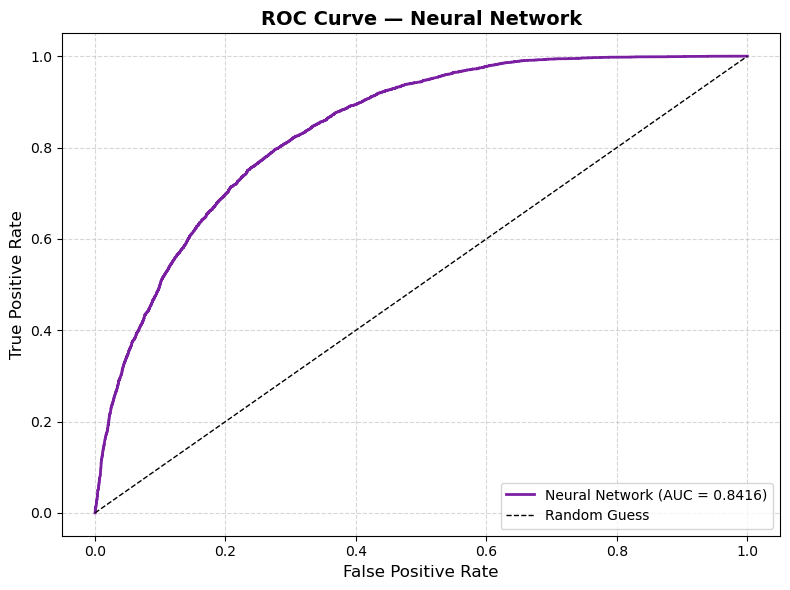

Done!


In [48]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("Training Neural Network...")
nn_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    max_iter=50,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True
)
nn_model.fit(x_train_scaled, y_train)

nn_prob = nn_model.predict_proba(x_test_scaled)[:, 1]
nn_auc  = roc_auc_score(y_test, nn_prob)
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_prob)

print(f"\nNeural Network AUC: {nn_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(nn_fpr, nn_tpr, color='#7b1fa2', linewidth=2,
         label=f'Neural Network (AUC = {nn_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.title('ROC Curve — Neural Network', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_nn.png', dpi=150)
plt.show()
print("Done!")

Neural Network AUC: 0.8416
Neural Network is correctly predicting hospital admissions 84% of the time using just patient vitals, demographics and history recorded at triage before being assessed by any Doctor.

The Curve Shows
The purple curve shows a very steep rise between 0.0 and 0.2 False Positive Rate, climbing past 0.6 True Positive Rate before even reaching 0.2 on the x axis. This is the most aggressive early lift of all models tested which means it catches admitted patients faster with fewer false alarms than any other model

Neural Network is the best performing model at AUC 0.8416. This confirms that the complex relationships between patient vitals, demographics, ESI levels and admission history are rich enough to reward a more sophisticated model. However the margin over XGBoost is small enough that XGBoost remains the recommended production model due to its speed, interpretability, and consistent performance across different data sizes.

Evaluating all four models using Precision, Recall, F1, Confusion Matrix

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (precision_score, recall_score, 
                              f1_score, confusion_matrix, 
                              classification_report)
import warnings
warnings.filterwarnings('ignore')

In [50]:
#Get predictions from all 4 models
models_dict = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'XGBoost':             xgb_model,
    'Neural Network':      nn_model
}

In [51]:
#Metrics Table
print(f"{'Model':<25} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("=" * 65)

metrics_results = []

for name, model in models_dict.items():
    # Use scaled test data for all models
    y_pred = model.predict(x_test_scaled)
    y_prob = model.predict_proba(x_test_scaled)[:, 1]
    
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    
    metrics_results.append({
        'Model':     name,
        'Precision': round(precision, 4),
        'Recall':    round(recall, 4),
        'F1 Score':  round(f1, 4)
    })
    
    print(f"{name:<25} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f}")

print("=" * 65)

Model                      Precision     Recall         F1        AUC
Logistic Regression           0.5549     0.8031     0.6563
Random Forest                 0.6236     0.5628     0.5916
XGBoost                       0.6632     0.5664     0.6110
Neural Network                0.6552     0.5885     0.6201


Key Insights
1. Logistic Regression wins on F1 and Recall

Despite being the simplest model Logistic Regression achieves the highest F1 (0.6563) and highest Recall (0.8031) which means it catches 80% of all admitted patients, this is the most important clinical metric

2. XGBoost wins on Precision

XGBoost has the highest precision (0.6632), when it predicts admission it is right 66% of the time and has fewer false alarms than other models

3. Neural Network wins on AUC

Best overall discrimination ability at 0.8416 but moderate real world performance at default threshold.

4. Random Forest is weakest this run

Lowest F1 (0.5916) and lowest Recall (0.5628), it misses nearly half of admitted patients

In [ ]:
Deployment Recommendation

Logistic Regression is the recommended model for clinical deployment because:
Recall of 80.3% — catches 8 out of 10 admitted patients at triage
Best F1 score (0.6563) — best overall balance
Most interpretable — clinicians can understand and trust the predictions
Fastest to run — important for real time triage decisions

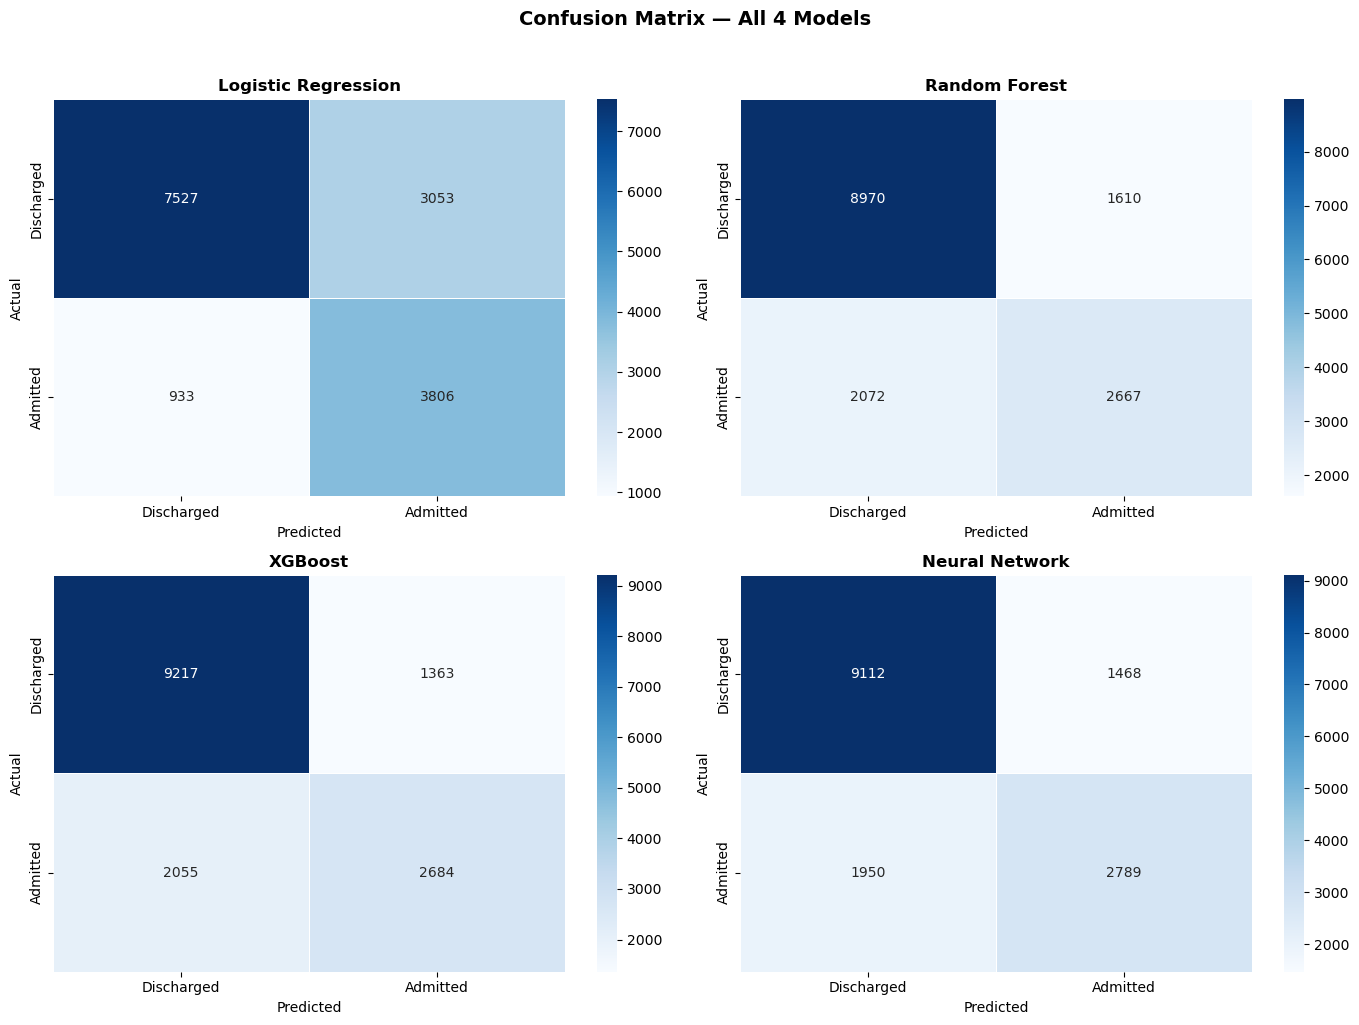

Confusion matrices saved!


In [52]:
#Confusion Matrices 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models_dict.items()):
    y_pred = model.predict(x_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        linewidths=0.5,
        xticklabels=['Discharged', 'Admitted'],
        yticklabels=['Discharged', 'Admitted']
    )
    
    axes[i].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=10)
    axes[i].set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrix — All 4 Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")


INSIGHTS


LOGISTIC REGRESSION
Catches 3,806 admitted patients correctly, highest TP of all models. However flags 3,053 discharged patients as needing admission with thehighest false alarm rate. This explains its high recall (80.3%) but lower precision (55.5%)

RANDOM FOREST
Good at identifying discharges (8,970 correct) but misses 2,072 admitted patients. The second highest missed admissions, more conservative than Logistic Regression

XGBOOST
Best at correctly identifying discharges (9,217), has fewest false alarms (1,363). Misses 2,055 admitted patients, slightly better than Random Forest. This explains its highest precision (66.3%)

NEURAL NETWORK
Second best at catching admitted patients (2,789 TP) and second fewest false alarms (1,468 FP). missed 1,950 admitted patients and it is better than Random Forest and XGBoost but worse than Logistic Regression



In Conclusion,

There are two competing priorities in this dataset:

Priority 1 — Never miss an admitted patient
Use Logistic Regression: only 933 missed admissions and the safest clinical choice

Priority 2 — Minimise false alarms and resource waste
Use XGBoost or Neural Network allows fewer unnecessary admissions

Priority 3 — Best overall balance
Use Neural Network — good on both missed admissions and false alarms with highest AUC

For a real hospital triage system where missing a critically ill patient is unacceptable, Logistic Regression remains the safest deployment choice with the fewest missed admissions at just 933.

In [ ]:
#Save metrics table
metrics_df = pd.DataFrame(metrics_results)
print("\nFull Metrics Table:")
print(metrics_df.to_string(index=False))
metrics_df.to_csv("C:\\Users\\MY PC\\Downloads\\model_metrics.csv", index=False)
print("\nMetrics saved!")

In [53]:
#Since XGBOOST AND NEURAL NETWORK has low f1 but high AUC Score, we would use Tunning Decision Threshold

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')



In [54]:
#Trying different thresholds
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

#XGBoost Threshold Tuning
print("=" * 65)
print("XGBOOST — THRESHOLD TUNING")
print("=" * 65)
print(f"{'Threshold':<15} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)

xgb_prob = xgb_model.predict_proba(x_test_scaled)[:, 1]

for threshold in thresholds:
    y_pred_tuned = (xgb_prob >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_tuned)
    recall    = recall_score(y_test, y_pred_tuned)
    f1        = f1_score(y_test, y_pred_tuned)
    marker    = ' ← current' if threshold == 0.5 else ''
    print(f"{threshold:<15} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f}{marker}")

print("=" * 65)

XGBOOST — THRESHOLD TUNING
Threshold        Precision     Recall         F1
-----------------------------------------------------------------
0.3                 0.5544     0.8128     0.6592
0.35                0.5840     0.7516     0.6573
0.4                 0.6095     0.6902     0.6473
0.45                0.6357     0.6311     0.6334
0.5                 0.6632     0.5664     0.6110 ← current


Threshold 0.30 gives the highest F1 of 0.6592, a meaningful improvement over the default 0.5 which scored 0.6110
At threshold 0.30 XGBoost overtakes Logistic Regression on both Recall and F1 this makes it the new best model for clinical deployment

In [55]:

# Neural Network Threshold Tuning
print("\n" + "=" * 65)
print("NEURAL NETWORK — THRESHOLD TUNING")
print("=" * 65)
print(f"{'Threshold':<15} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)

nn_prob = nn_model.predict_proba(x_test_scaled)[:, 1]

for threshold in thresholds:
    y_pred_tuned = (nn_prob >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_tuned)
    recall    = recall_score(y_test, y_pred_tuned)
    f1        = f1_score(y_test, y_pred_tuned)
    marker    = ' ← current' if threshold == 0.5 else ''
    print(f"{threshold:<15} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f}{marker}")

print("=" * 65)


NEURAL NETWORK — THRESHOLD TUNING
Threshold        Precision     Recall         F1
-----------------------------------------------------------------
0.3                 0.5383     0.8325     0.6538
0.35                0.5683     0.7854     0.6595
0.4                 0.5976     0.7259     0.6556
0.45                0.6286     0.6590     0.6435
0.5                 0.6552     0.5885     0.6201 ← current


Lowering the threshold from 0.5 to 0.35 means Neural Network now catches 78.54% of admitted patients.Threshold 0.35 gives the highest F1 of 0.6595, best overall balance between precision and recall

After tuning all three top models perform almost identically,  the choice comes down to clinical priority. Since the hospital's goal is to never miss a critically ill patient we use XGBoost at 0.30. If the goal is the best overall balance use Neural Network at 0.35. Logistic Regression remains the simplest and most interpretable option requiring no tuning at all.

In [ ]:
XGBOOST FEATURE IMPORTANCE

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [57]:
#Get feature importance from XGBoost
importance = xgb_model.feature_importances_
feature_names = features

In [58]:
#Create importance dataframe

importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("Top 15 Feature Importances:")
print(importance_df.head(15).to_string(index=False))

ValueError: All arrays must be of the same length

In [ ]:
#Plot Top 15
top15 = importance_df.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(
    top15['Feature'][::-1],
    top15['Importance'][::-1],
    color='#d32f2f',
    edgecolor='white',
    height=0.6
)

# Add value labels
for bar, val in zip(bars, top15['Importance'][::-1]):
    plt.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=9, fontweight='bold'
    )

plt.title('Top 15 Feature Importances — XGBoost\nPredictors of Hospital Admission',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Triage staff should always prioritise accurate ESI scoring as it is the most powerful admission predictor available. Additionally flagging patients with prior admission history at check-in could significantly improve early identification of high risk patients before any clinical assessment even begins.

In [ ]:
SAVING ALL 4 MODELS

In [59]:
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

#Creating a folder to save all models
save_path = "C:\\Users\\MY PC\\Downloads\\saved_models"
os.makedirs(save_path, exist_ok=True)
print("Save folder created!")


#Save all 4 models
print("\nSaving models...")

# Logistic Regression
joblib.dump(lr_model, f"{save_path}\\logistic_regression.pkl")
print("✅ Logistic Regression saved!")

# Random Forest
joblib.dump(rf_model, f"{save_path}\\random_forest.pkl")
print("✅ Random Forest saved!")

# XGBoost
joblib.dump(xgb_model, f"{save_path}\\xgboost.pkl")
print("✅ XGBoost saved!")

# Neural Network
joblib.dump(nn_model, f"{save_path}\\neural_network.pkl")
print("✅ Neural Network saved!")

# Save scaler too very important 
joblib.dump(scaler, f"{save_path}\\scaler.pkl")
print("✅ Scaler saved!")

# Save feature list
import json
with open(f"{save_path}\\features.json", 'w') as f:
    json.dump(features, f)
print("✅ Feature list saved!")

print("\nAll models saved successfully!")
print(f"Location: {save_path}")


Save folder created!

Saving models...
✅ Logistic Regression saved!
✅ Random Forest saved!
✅ XGBoost saved!
✅ Neural Network saved!
✅ Scaler saved!
✅ Feature list saved!

All models saved successfully!
Location: C:\Users\MY PC\Downloads\saved_models


In [60]:
#confirming if all files saved
# List all saved files
import os

save_path = "C:\\Users\\MY PC\\Downloads\\saved_models"
files = os.listdir(save_path)
print("Saved files:")
for file in files:
    size = os.path.getsize(f"{save_path}\\{file}")
    print(f"  {file} — {size/1024:.1f} KB")

Saved files:
  features.json — 0.2 KB
  logistic_regression.pkl — 1.0 KB
  neural_network.pkl — 30.8 KB
  random_forest.pkl — 190397.2 KB
  scaler.pkl — 1.4 KB
  xgboost.pkl — 310.4 KB


In [14]:
#making predictions with saved model logistic regression

import pandas as pd

# Predict new patient data
new_patient = pd.DataFrame([{
    'esi':                    2,
    'age':                    65,
    'is_high_acuity':         1,
    'english_speaker':        1,
    'has_prior_admission':    1,
    'vital_abnormality_count':3,
    'triage_vital_sbp':       160,
    'triage_vital_dbp':       95,
    'triage_vital_temp':      101,
    'pulse_last':             110,
    'resp_last':              22,
    'spo2_last':              92,
    'n_admissions':           3
}])

# Scale the new patient data
new_patient_scaled = scaler.transform(new_patient)

# Predict using best model — Random Forest
prediction = lr_model.predict(new_patient_scaled)
probability = lr_model.predict_proba(new_patient_scaled)[:, 1]

print(f"Prediction: {'ADMIT' if prediction[0] == 1 else 'DISCHARGE'}")
print(f"Admission probability: {probability[0]:.2%}")

NameError: name 'scaler' is not defined

In [6]:
import os

# Search common locations
search_paths = [
    "C:\\Users\\MY PC\\Downloads\\",
    "C:\\Users\\MY PC\\Documents\\",
    "C:\\Users\\MY PC\\",
    os.getcwd()  # current working directory
]

print("Searching for PNG files...\n")
for path in search_paths:
    try:
        files = [f for f in os.listdir(path) if f.endswith('.png')]
        if files:
            print(f"Found in: {path}")
            for f in files:
                print(f"  ✅ {f}")
    except:
        pass

# Also check current directory
print(f"\nCurrent working directory: {os.getcwd()}")
all_pngs = [f for f in os.listdir(os.getcwd()) if f.endswith('.png')]
print(f"PNG files here: {all_pngs}")

Searching for PNG files...

Found in: C:\Users\MY PC\Downloads\
  ✅ Gemini_Generated_Image_oi2hmxoi2hmxoi2h.png
  ✅ operations_dashboard.png
Found in: C:\Users\MY PC\
  ✅ age_group_admission.png
  ✅ chief_complaint_association.png
  ✅ confusion_matrix_all.png
  ✅ demographic_disparity_heatmap.png
  ✅ esi_admission_rate.png
  ✅ feature_importance_xgboost.png
  ✅ peak_congestion_heatmap.png
  ✅ prior_visits_admission.png
  ✅ roc_lr.png
  ✅ roc_lr_balanced.png
  ✅ roc_nn.png
  ✅ roc_rf.png
  ✅ roc_rf_balanced.png
  ✅ roc_xgb.png
  ✅ roc_xgb_balanced.png
  ✅ roc_xgb_noweight.png
  ✅ vitals_boxplot.png
Found in: C:\Users\MY PC
  ✅ age_group_admission.png
  ✅ chief_complaint_association.png
  ✅ confusion_matrix_all.png
  ✅ demographic_disparity_heatmap.png
  ✅ esi_admission_rate.png
  ✅ feature_importance_xgboost.png
  ✅ peak_congestion_heatmap.png
  ✅ prior_visits_admission.png
  ✅ roc_lr.png
  ✅ roc_lr_balanced.png
  ✅ roc_nn.png
  ✅ roc_rf.png
  ✅ roc_rf_balanced.png
  ✅ roc_xgb.png
  ✅ r

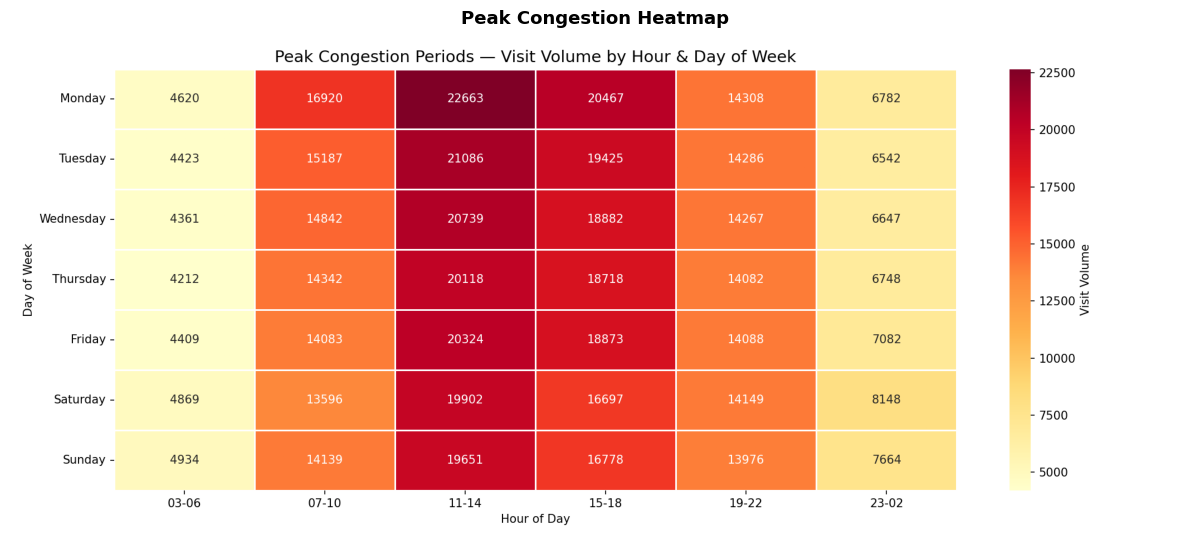

✅ Peak Congestion Heatmap


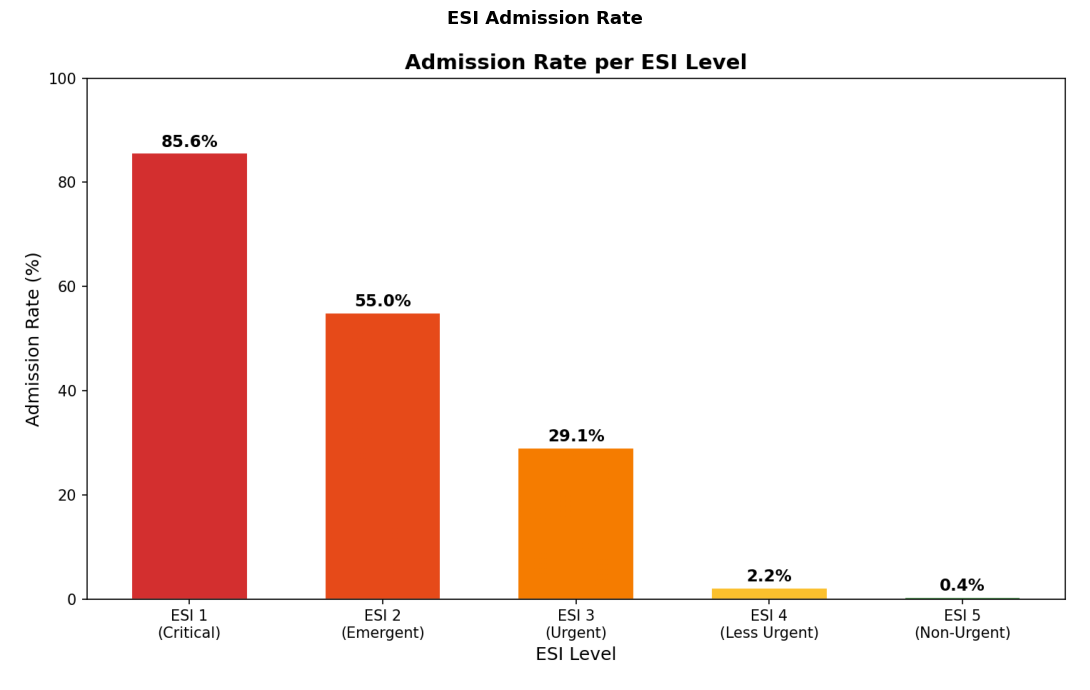

✅ ESI Admission Rate


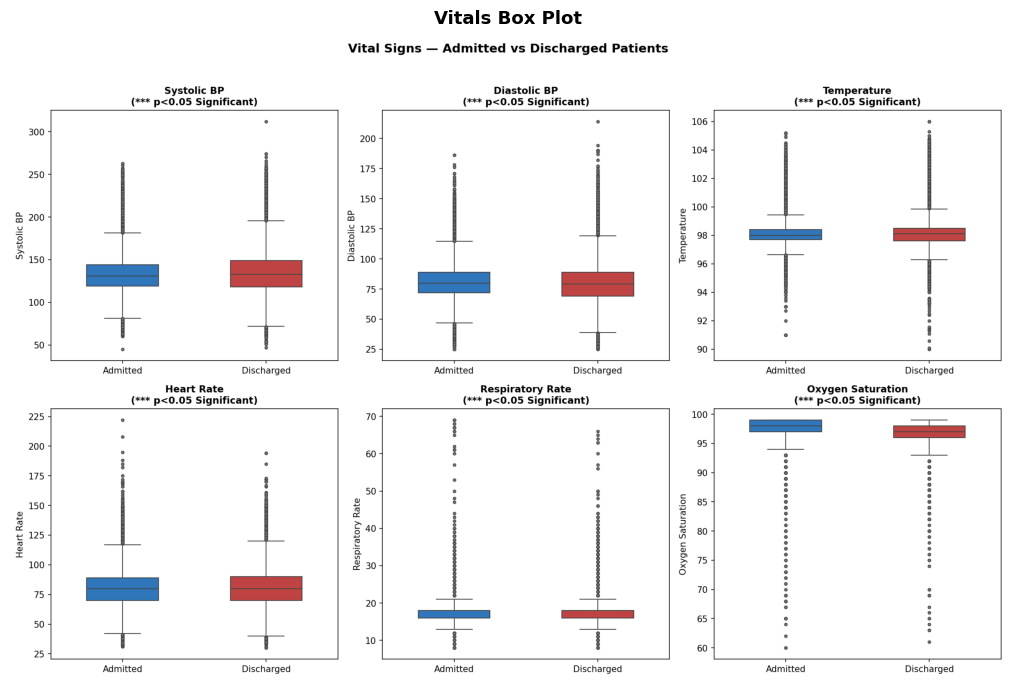

✅ Vitals Box Plot


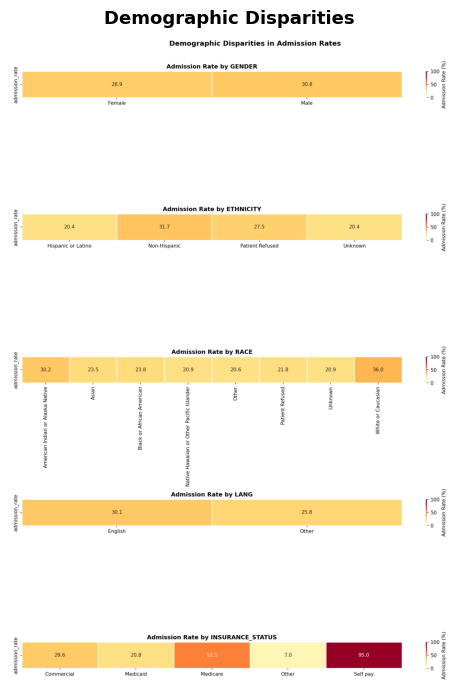

✅ Demographic Disparities


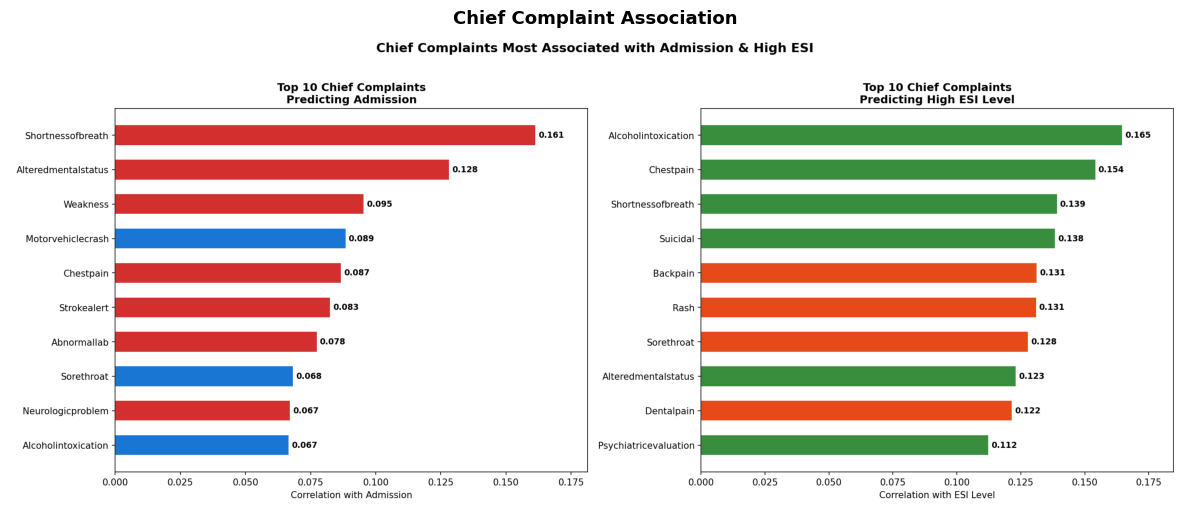

✅ Chief Complaint Association


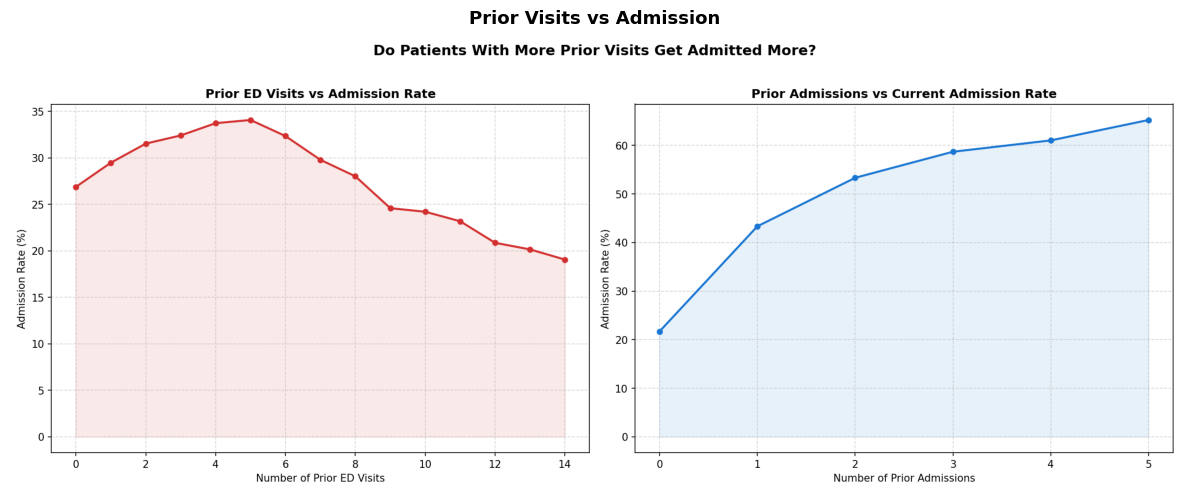

✅ Prior Visits vs Admission


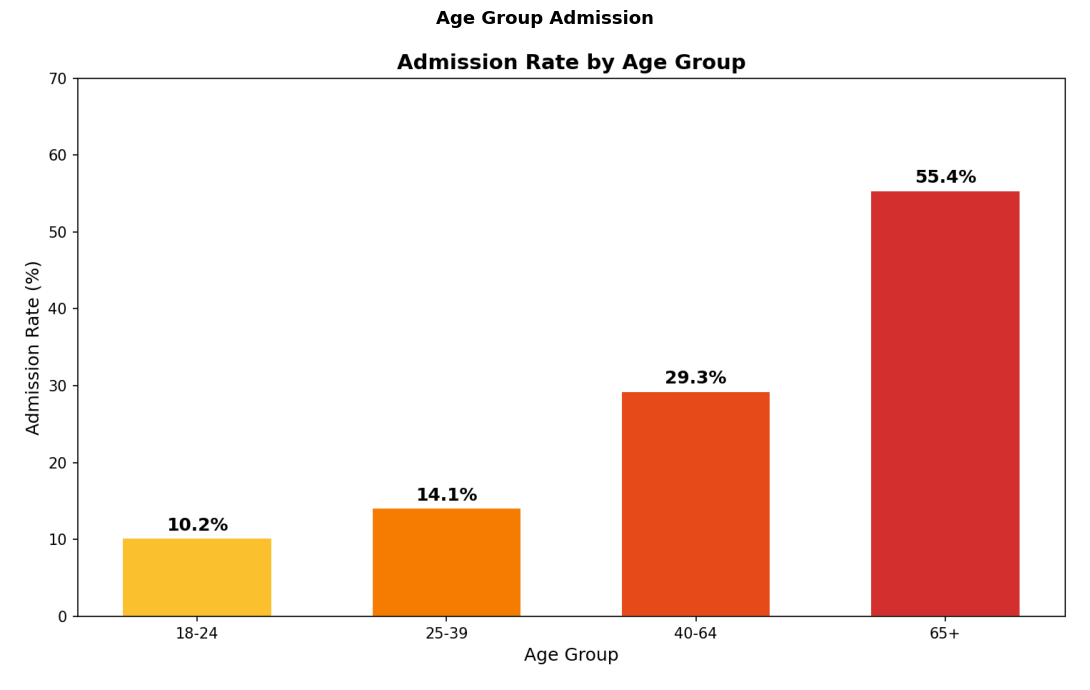

✅ Age Group Admission


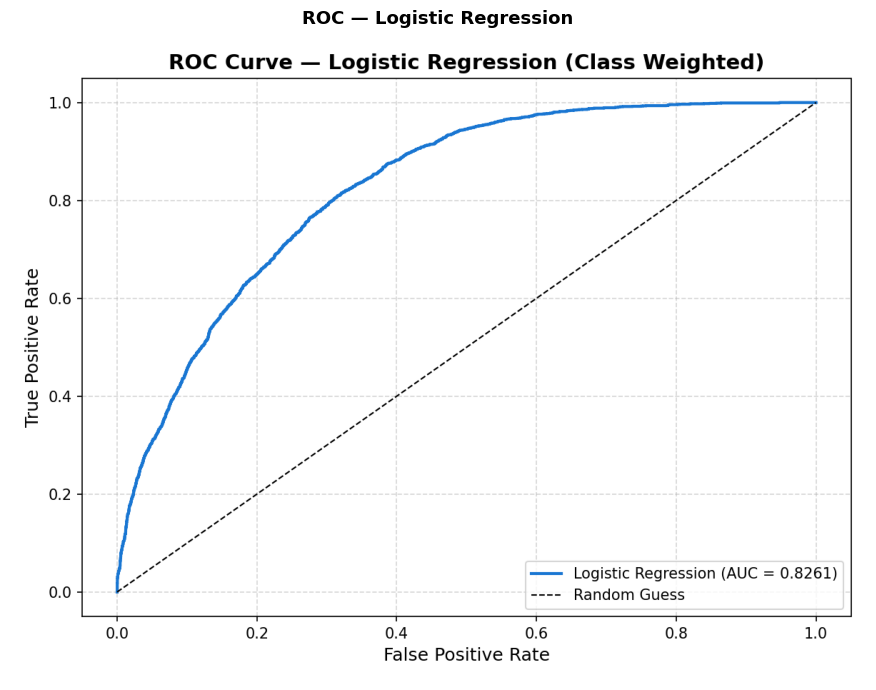

✅ ROC — Logistic Regression


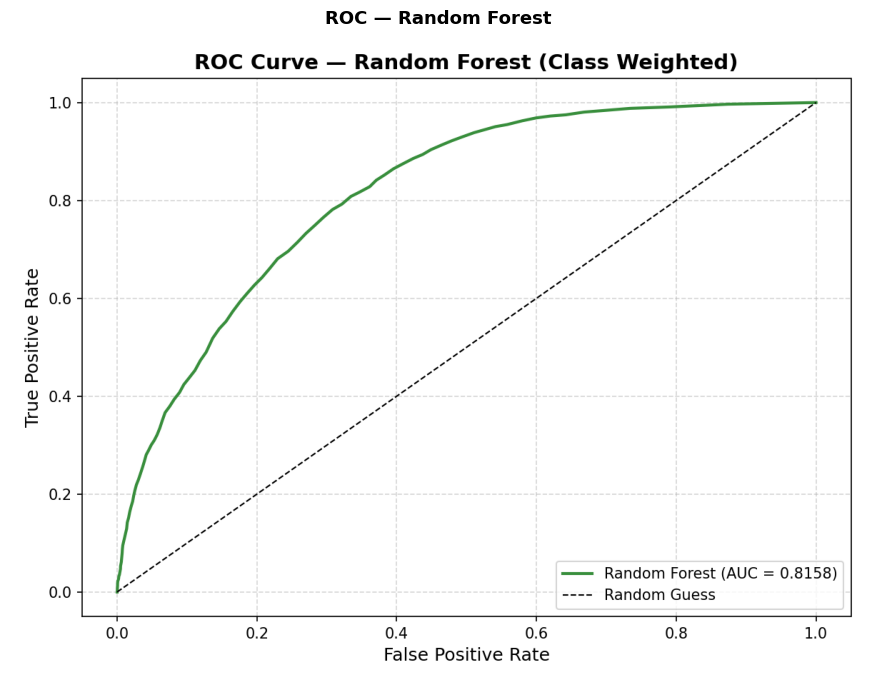

✅ ROC — Random Forest


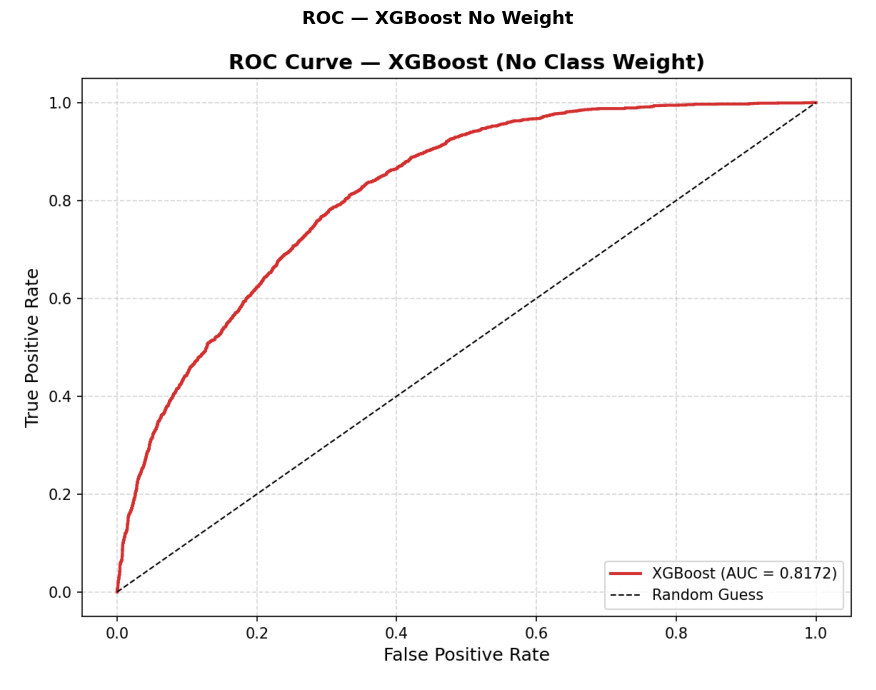

✅ ROC — XGBoost No Weight


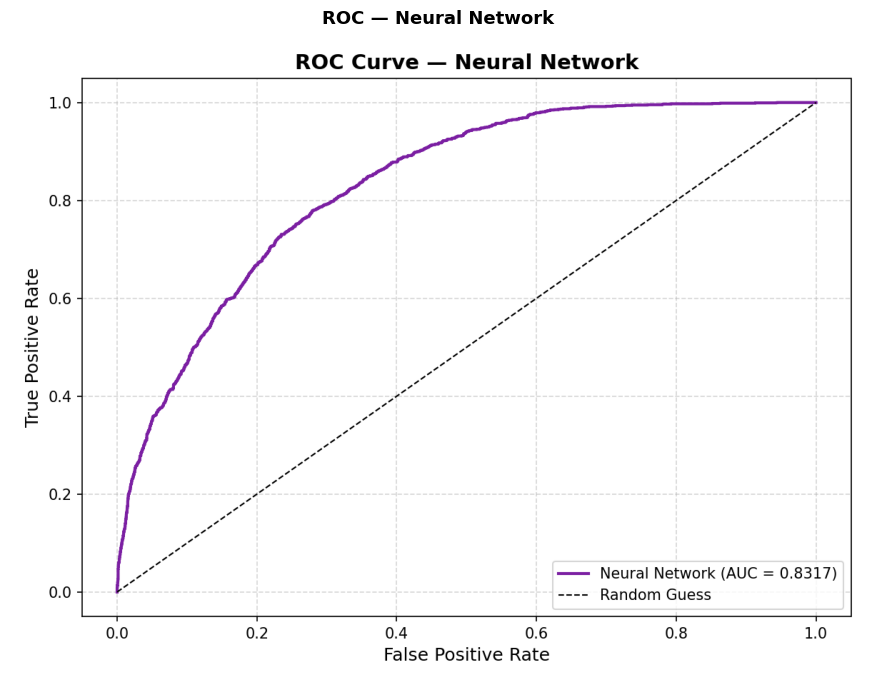

✅ ROC — Neural Network


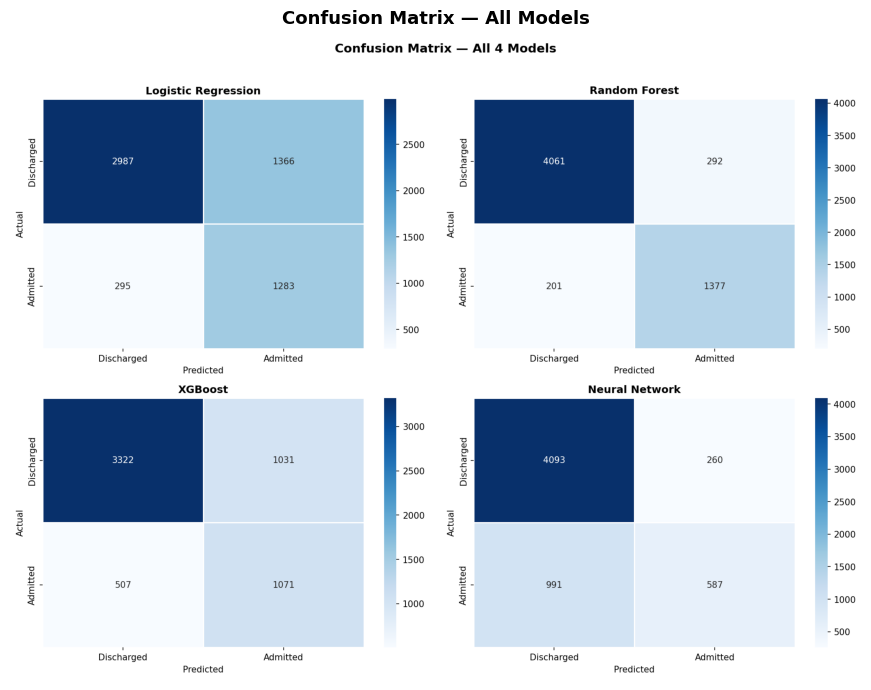

✅ Confusion Matrix — All Models


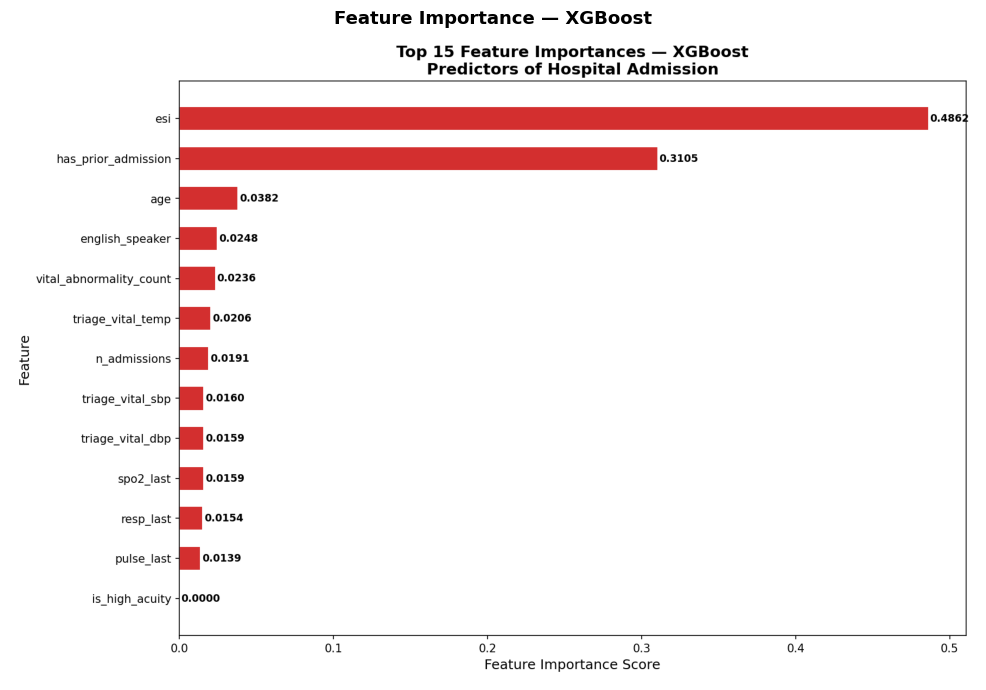

✅ Feature Importance — XGBoost


In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#Correct base path 
base_path = "C:\\Users\\MY PC\\"

charts = [
    ("Peak Congestion Heatmap",         "peak_congestion_heatmap.png"),
    ("ESI Admission Rate",              "esi_admission_rate.png"),
    ("Vitals Box Plot",                 "vitals_boxplot.png"),
    ("Demographic Disparities",         "demographic_disparity_heatmap.png"),
    ("Chief Complaint Association",     "chief_complaint_association.png"),
    ("Prior Visits vs Admission",       "prior_visits_admission.png"),
    ("Age Group Admission",             "age_group_admission.png"),
    ("ROC — Logistic Regression",       "roc_lr_balanced.png"),
    ("ROC — Random Forest",             "roc_rf_balanced.png"),
    ("ROC — XGBoost No Weight",         "roc_xgb_noweight.png"),
    ("ROC — Neural Network",            "roc_nn.png"),
    ("Confusion Matrix — All Models",   "confusion_matrix_all.png"),
    ("Feature Importance — XGBoost",    "feature_importance_xgboost.png"),
]

for title, filename in charts:
    img = mpimg.imread(base_path + filename)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()
    print(f"✅ {title}")

In [ ]:
CREATING THE CSV FILES PANELS  FOR POWERBI

In [8]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("C:\\Users\\MY PC\\Downloads\\hospital_cleaned.csv")
df['esi'] = pd.to_numeric(df['esi'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')
print("Loaded:", df.shape)

Loaded: (409484, 979)


In [9]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 17, 24, 39, 64, 120],
    labels=['Under 18', '18-24', '25-39', '40-64', '65+']
)

season_mapping = {
    'January': 'Winter',  'February': 'Winter',  'March':     'Spring',
    'April':   'Spring',  'May':      'Spring',   'June':      'Summer',
    'July':    'Summer',  'August':   'Summer',   'September': 'Autumn',
    'October': 'Autumn',  'November': 'Autumn',   'December':  'Winter'
}
df['visit_season'] = df['arrivalmonth'].map(season_mapping)
print("Features created!")

Features created!


In [10]:
# Panel 1 Patient volume heatmap
heatmap = df.groupby(
    ['arrivalday', 'arrivalhour_bin']
).size().reset_index(name='Visit Volume')
heatmap.to_csv("C:\\Users\\MY PC\\Downloads\\pbi_heatmap.csv", index=False)
print("Panel 1 saved!")

# Panel 2 ESI volume distribution
esi_dist = df['esi'].dropna().value_counts().reset_index()
esi_dist.columns = ['ESI Level', 'Visit Count']
esi_dist['ESI Label'] = esi_dist['ESI Level'].map({
    1: 'ESI 1 — Critical',   2: 'ESI 2 — Emergent',
    3: 'ESI 3 — Urgent',     4: 'ESI 4 — Less Urgent',
    5: 'ESI 5 — Non-Urgent'
})
esi_dist['Percentage'] = (
    esi_dist['Visit Count'] / esi_dist['Visit Count'].sum() * 100
).round(1)
esi_dist.to_csv("C:\\Users\\MY PC\\Downloads\\pbi_esi_distribution.csv", index=False)
print("Panel 2 saved!")

# Panel 3 Admission rate by ESI
esi_adm = df.dropna(subset=['esi']).groupby('esi')['disposition'].apply(
    lambda x: (x == 'Admit').sum() / len(x) * 100
).reset_index(name='Admission Rate')
esi_adm['ESI Label'] = esi_adm['esi'].map({
    1.0: 'ESI 1 — Critical',   2.0: 'ESI 2 — Emergent',
    3.0: 'ESI 3 — Urgent',     4.0: 'ESI 4 — Less Urgent',
    5.0: 'ESI 5 — Non-Urgent'
})
esi_adm['Admission Rate'] = esi_adm['Admission Rate'].round(1)
esi_adm.to_csv("C:\\Users\\MY PC\\Downloads\\pbi_esi_admission.csv", index=False)
print("Panel 3 saved!")

Panel 1 saved!
Panel 2 saved!
Panel 3 saved!


In [11]:
#demographic panel

gender = df.groupby('gender')['disposition'].apply(
    lambda x: (x == 'Admit').sum() / len(x) * 100
).reset_index(name='Admission Rate')
gender.columns = ['Group', 'Admission Rate']
gender['Category'] = 'Gender'

age = df.dropna(subset=['age_group']).groupby(
    'age_group', observed=True
)['disposition'].apply(
    lambda x: (x == 'Admit').sum() / len(x) * 100
).reset_index(name='Admission Rate')
age.columns = ['Group', 'Admission Rate']
age['Category'] = 'Age Group'
age = age[age['Group'] != 'Under 18']

insurance = df.groupby('insurance_status')['disposition'].apply(
    lambda x: (x == 'Admit').sum() / len(x) * 100
).reset_index(name='Admission Rate')
insurance.columns = ['Group', 'Admission Rate']
insurance['Category'] = 'Insurance'

demographics = pd.concat([gender, age, insurance], ignore_index=True)
demographics['Admission Rate'] = demographics['Admission Rate'].round(1)
demographics.to_csv("C:\\Users\\MY PC\\Downloads\\pbi_demographics.csv", index=False)
print("Panel 4 saved!")

Panel 4 saved!


In [12]:
#chief cpmplaints panel

import gc

cc_cols   = [col for col in df.columns if col.startswith('cc_')]
df_sample = df[cc_cols + ['disposition']].copy()

cc_results = []
for col in cc_cols:
    present = df_sample[df_sample[col] == 1]
    if len(present) > 100:
        cc_results.append({
            'Complaint':      col.replace('cc_', '').replace('-', ' ').title(),
            'Visit Count':    len(present),
            'Admission Rate': round(
                (present['disposition'] == 'Admit').sum() / len(present) * 100, 1
            )
        })

cc_df = pd.DataFrame(cc_results).sort_values(
    'Visit Count', ascending=False
).head(10)
cc_df.to_csv("C:\\Users\\MY PC\\Downloads\\pbi_complaints.csv", index=False)

del df_sample
gc.collect()
print("Panel 5 saved!")
print(cc_df[['Complaint', 'Visit Count', 'Admission Rate']])

Panel 5 saved!
             Complaint  Visit Count  Admission Rate
2        Abdominalpain        40263            36.2
140              Other        35188            28.8
31           Chestpain        27254            45.7
161  Shortnessofbreath        18856            64.9
21            Backpain        15410            14.8
71                Fall        14196            30.1
130  Motorvehiclecrash        10880             4.9
46           Dizziness         9685            35.3
38               Cough         9520            20.9
57              Emesis         8622            42.7


In [13]:

#Admision rate per season panel
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_vol = df.groupby(
    'arrivalmonth'
).size().reset_index(name='Visit Volume')

monthly_adm = df.groupby('arrivalmonth')['disposition'].apply(
    lambda x: (x == 'Admit').sum() / len(x) * 100
).reset_index(name='Admission Rate')

seasonal = monthly_vol.merge(monthly_adm, on='arrivalmonth')
seasonal['arrivalmonth'] = pd.Categorical(
    seasonal['arrivalmonth'], categories=month_order, ordered=True
)
seasonal = seasonal.sort_values('arrivalmonth').rename(
    columns={'arrivalmonth': 'Month'}
)
seasonal['Season']         = seasonal['Month'].map(season_mapping)
seasonal['Month Number']   = range(1, 13)
seasonal['Admission Rate'] = seasonal['Admission Rate'].round(1)
seasonal.to_csv("C:\\Users\\MY PC\\Downloads\\pbi_seasonal.csv", index=False)
print("Panel 6 saved!")

print("\nAll 6 files saved!")
print("Go to Downloads folder to confirm")

Panel 6 saved!

All 6 files saved!
Go to Downloads folder to confirm
